In [7]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Image, display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
OUTPUT_DIR = "/content/"

BENIGN_PATH    = "master_regionalizado/benigno_latam_50k.csv"
MALICIOUS_PATH = "master_regionalizado/phishing_latam_50k.csv"

# ---------------------------------------------------------------------------
# 1. UNIÓN DE DATASETS Y CREACIÓN DE ESTRATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Unión de datasets y clasificación")
print("=" * 70)

benign = pd.read_csv(BENIGN_PATH)
malig  = pd.read_csv(MALICIOUS_PATH)

# Add 'label' column with value 0 for benign URLs
benign['label'] = 0

# Remover protocolo y www. de las URLs
def remove_protocol(url):
    return re.sub(r"^(?:https?://)?(?:www\.)?", "", str(url).strip(), flags=re.IGNORECASE)

benign['url'] = benign['url'].apply(remove_protocol)
malig['url']  = malig['url'].apply(remove_protocol)

pocos_paises = ['El Salvador', 'Guatemala', 'Honduras', 'Panamá', 'Nicaragua']

# Clasificar malignas en sus 3 grupos
def grupo_maligno(row):
    pais = row['pais']
    if pd.isna(pais) or pais == 'Generico' or pais == 'Pais Generico':
        return 'generico_phishing'
    elif pais in pocos_paises:
        return 'Latam_pocos_paises_phishing'
    else:
        return str(pais) + '_phishing' # Use country name for stratum

# Clasificar benignos
def grupo_benigno(row):
    pais = row['pais']
    if pd.isna(pais) or pais == 'Generico' or pais == 'Pais Generico':
        return 'generico_benigno'
    elif pais in pocos_paises:
        return 'Latam_pocos_paises_benigno'
    else:
        return str(pais) + '_benigno' # Use country code for stratum

malig['estrato'] = malig.apply(grupo_maligno, axis=1)
benign['estrato'] = benign.apply(grupo_benigno, axis=1)

# Asegurar que dominio esté presente
benign.rename(columns={'dominio': 'domain'}, inplace=True)
malig.rename(columns={'dominio': 'domain'}, inplace=True)

# Unir
df = pd.concat(
    [benign[['url', 'domain', 'label', 'estrato']],
     malig[['url', 'domain', 'label', 'estrato']]],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Limpieza básica
df = df.dropna(subset=["url"])
df = df[df["url"].str.len() > 3]
df = df.drop_duplicates(subset=["url"])
df = df.reset_index(drop=True)

print(f"  Total tras unión   : {len(df):,}")
print(f"  Distribución de clases:\n{df['label'].value_counts().to_string()}")
print(f"\n  Distribución de estratos:\n{df['estrato'].value_counts().to_string()}")

# Guardar CSV unido
merged_path = os.path.join(OUTPUT_DIR, "dataset_merged.csv")
df.to_csv(merged_path, index=False)
print(f"\n  ✓ Guardado: {merged_path}")

print(f"\n  Unique strata generated:\n{df['estrato'].unique()}")

ETAPA 1 – Unión de datasets y clasificación
  Total tras unión   : 100,000
  Distribución de clases:
label
1    50000
0    50000

  Distribución de estratos:
estrato
generico_phishing              25000
generico_benigno               25000
Colombia_benigno               11477
Colombia_phishing              11477
Brasil_benigno                  7443
Brasil_phishing                 7443
México_benigno                  1791
México_phishing                 1791
Chile_benigno                   1701
Chile_phishing                  1701
Argentina_benigno               1011
Argentina_phishing              1011
Perú_phishing                    692
Perú_benigno                     692
Uruguay_benigno                  219
Uruguay_phishing                 219
Ecuador_phishing                 149
Ecuador_benigno                  149
Venezuela_benigno                120
Venezuela_phishing               120
Latam_pocos_paises_benigno       105
Latam_pocos_paises_phishing      105
Paraguay_benigno    

In [1]:
!pip install optuna -q
import optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.0 MB/s eta 0:00:00


ETAPA 1 – Carga del Dataset
  Total muestras : 100,000
  Benignas (0)   : 50,000
  Maliciosas (1) : 50,000
  Estratos únicos: 30

ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)
         por estrato
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)

  Estratos únicos – Train: 30 | Val: 30 | Test: 30

ETAPA 3 – Tokenización a nivel de carácter, Embeddings y Padding
  Tamaño de vocabulario de caracteres: 124
  Longitud máxima (percentil 95): 100 caracteres
  Tokenizando splits...
  X_train shape: (70000, 100) | y_train shape: (70000,)
  X_val   shape: (15000, 100)   | y_val   shape: (15000,)
  X_test  shape: (15000, 100)  | y_test  shape: (15000,)

  ✓ Guardado tokens (muestra): outputs_bilstm/preprocessing_tokens.csv


[I 2026-06-04 13:24:26,555] A new study created in memory with name: no-name-67b97d11-519d-4e13-881d-d45f1667bedc


  ✓ Guardado embeddings (muestra): outputs_bilstm/preprocessing_embeddings.csv
  ✓ Guardado padding (muestra): outputs_bilstm/preprocessing_padding.csv

  Vocab size        : 124
  Emb dim (default) : 64
  Max length        : 100

  Dispositivo de cómputo: cuda

ETAPA 4 – Búsqueda de Hiperparámetros con Optuna
Iniciando optimización con Optuna (50 trials)...


[I 2026-06-04 13:24:51,272] Trial 0 finished with value: 0.2853053648630778 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.4641163877192719, 'lr': 0.0011823879131348059, 'emb_dim': 128, 'batch_size': 128, 'weight_decay': 5.2243370882917234e-05}. Best is trial 0 with value: 0.2853053648630778.
[I 2026-06-04 13:25:15,935] Trial 1 finished with value: 0.35938880707422893 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.5088349119329272, 'lr': 0.0005543809752652203, 'emb_dim': 64, 'batch_size': 128, 'weight_decay': 2.1736488077633915e-05}. Best is trial 0 with value: 0.2853053648630778.
[I 2026-06-04 13:27:01,464] Trial 2 finished with value: 0.4595245194753011 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4805760392746007, 'lr': 0.000516849502151939, 'emb_dim': 128, 'batch_size': 32, 'weight_decay': 0.0040448690265052455}. Best is trial 0 with value: 0.2853053648630778.
[I 2026-06-04 13:27:30,997] Trial 3 finished with value: 0.47598318


🏆 Mejores hiperparámetros encontrados:
  hidden_dim: 128
  num_layers: 3
  dropout: 0.3015027901023623
  lr: 0.0011115382239684285
  emb_dim: 128
  batch_size: 128
  weight_decay: 1.8196064226909476e-05

ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)
  Épocas máx: 50
  Checkpoint: score generalización (val_loss + gap train-val)
  EarlyStopping: patience=5, min_delta=0.0001
  pos_weight (neg/pos): 1.0000
  Época   1/50 * | Loss → Train: 0.4678  Val: 0.3439 | Acc  → Train: 0.7964  Val: 0.8804 | Gen: 0.3439 (gap L/A: 0.0000/0.0000) | LR: 1.11e-03 | Tiempo: 9.5s
  Época   5/50 * | Loss → Train: 0.2562  Val: 0.2570 | Acc  → Train: 0.9307  Val: 0.9307 | Gen: 0.2578 (gap L/A: 0.0008/0.0000) | LR: 1.11e-03 | Tiempo: 47.6s
  Época  10/50 | Loss → Train: 0.2178  Val: 0.2410 | Acc  → Train: 0.9519  Val: 0.9395 | Gen: 0.2703 (gap L/A: 0.0232/0.0124) | LR: 1.11e-03 | Tiempo: 95.2s
  ⏹ EarlyStoppin

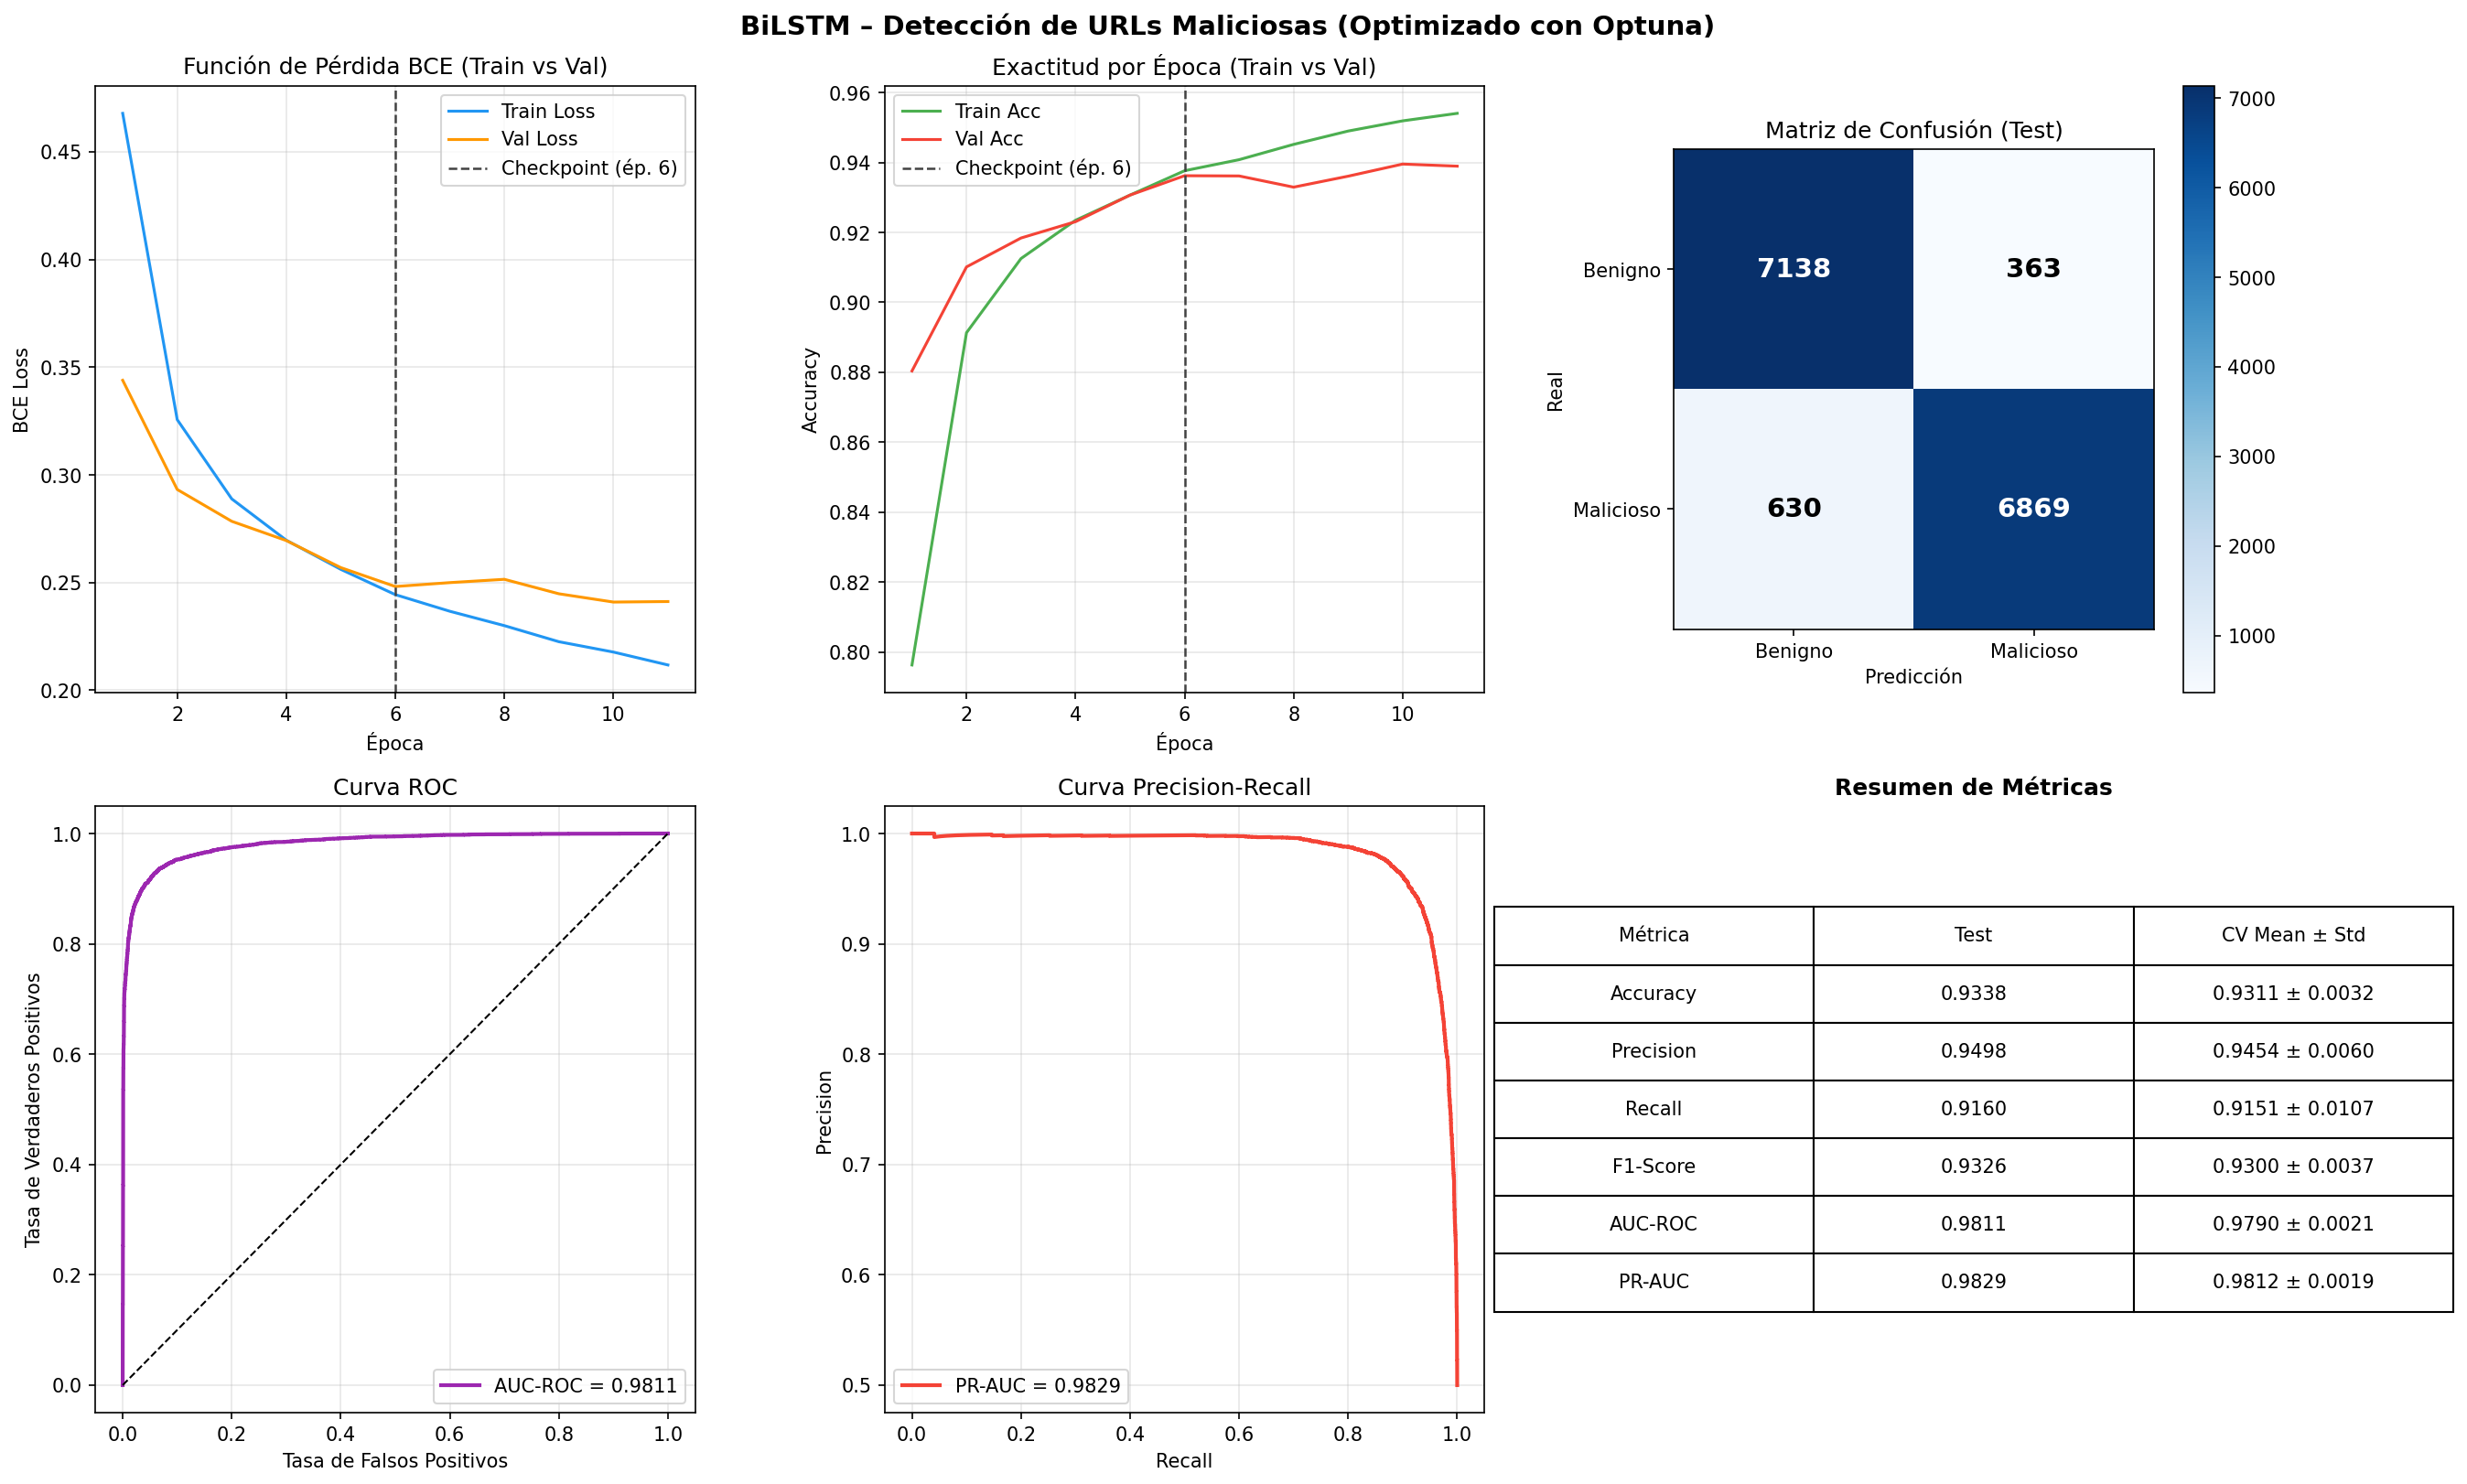


ETAPA 7a – Test Externo LATAM
  [LATAM] URLs con protocolo / www. eliminado: 920 de 3,000 (30.7 %)
  [LATAM] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test LATAM
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test LATAM] ⚠  163 URLs (5.4%) superan MAX_LEN=100 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test LATAM                                 │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9350                      │
  │  Precisión (Precision)   │  0.9347                      │
  │  Exhaustividad (Recall)  │  0.9353                      │
  │  F1-Score                │  0.9350                      │
  │  AUC-ROC                 │  0.9801                      │
  │  PR-AUC                  │  0.9831                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
              P

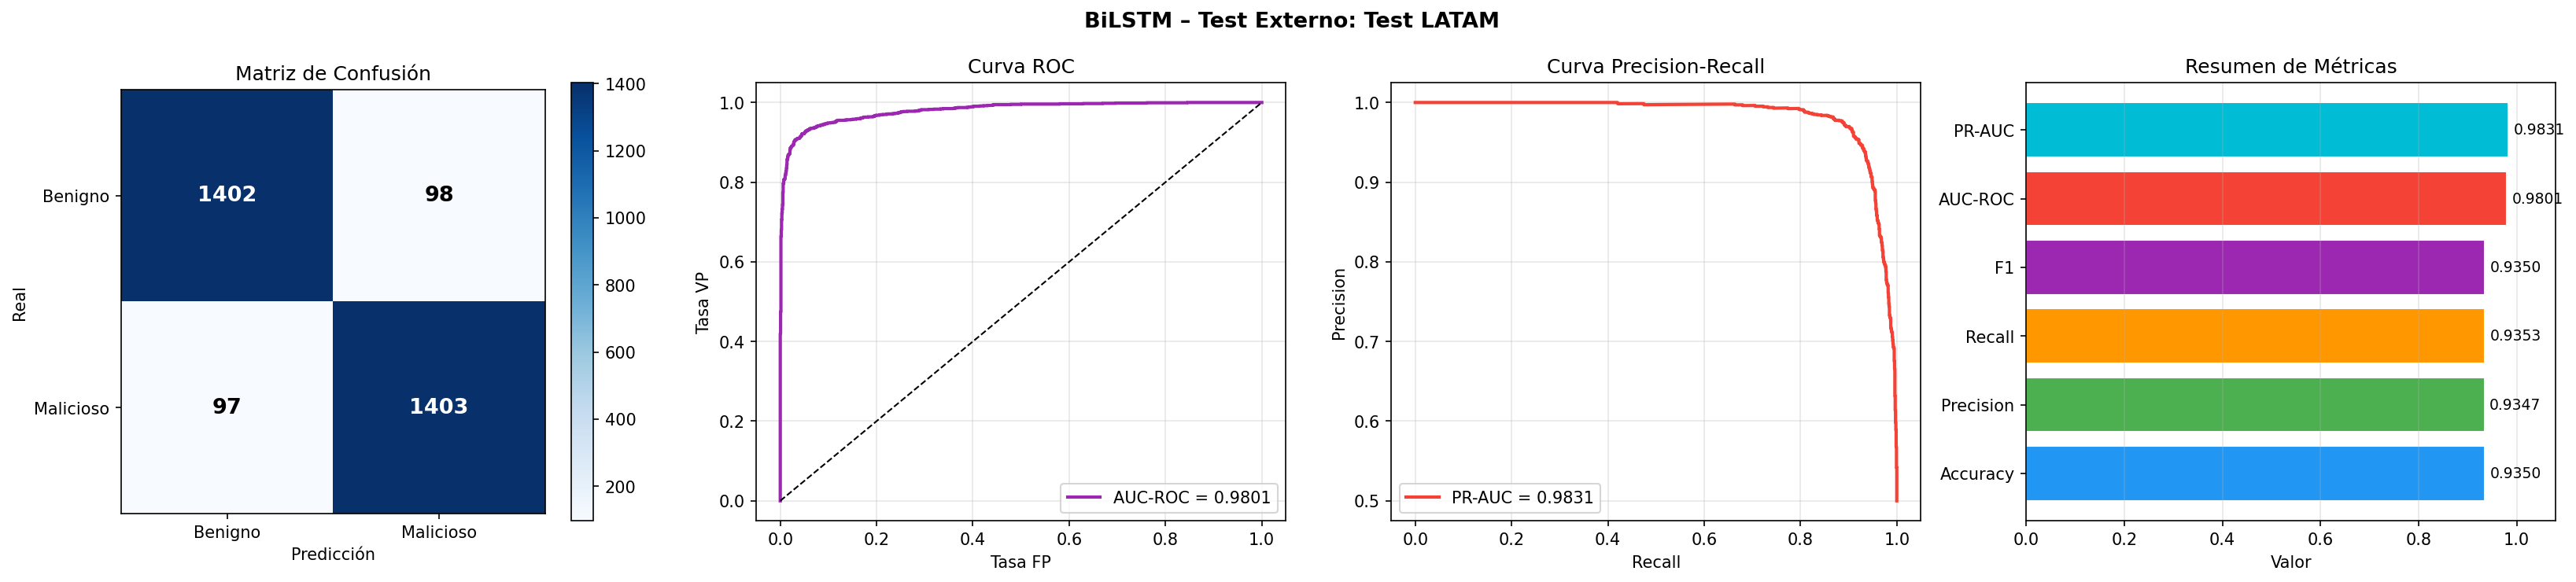


ETAPA 7b – Test Externo Genérico
  [Genérico] URLs con protocolo / www. eliminado: 0 de 3,000 (0.0 %)
  [Genérico] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test Genérico
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test Genérico] ⚠  234 URLs (7.8%) superan MAX_LEN=100 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test Genérico                              │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9283                      │
  │  Precisión (Precision)   │  0.9554                      │
  │  Exhaustividad (Recall)  │  0.8987                      │
  │  F1-Score                │  0.9261                      │
  │  AUC-ROC                 │  0.9851                      │
  │  PR-AUC                  │  0.9841                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
   

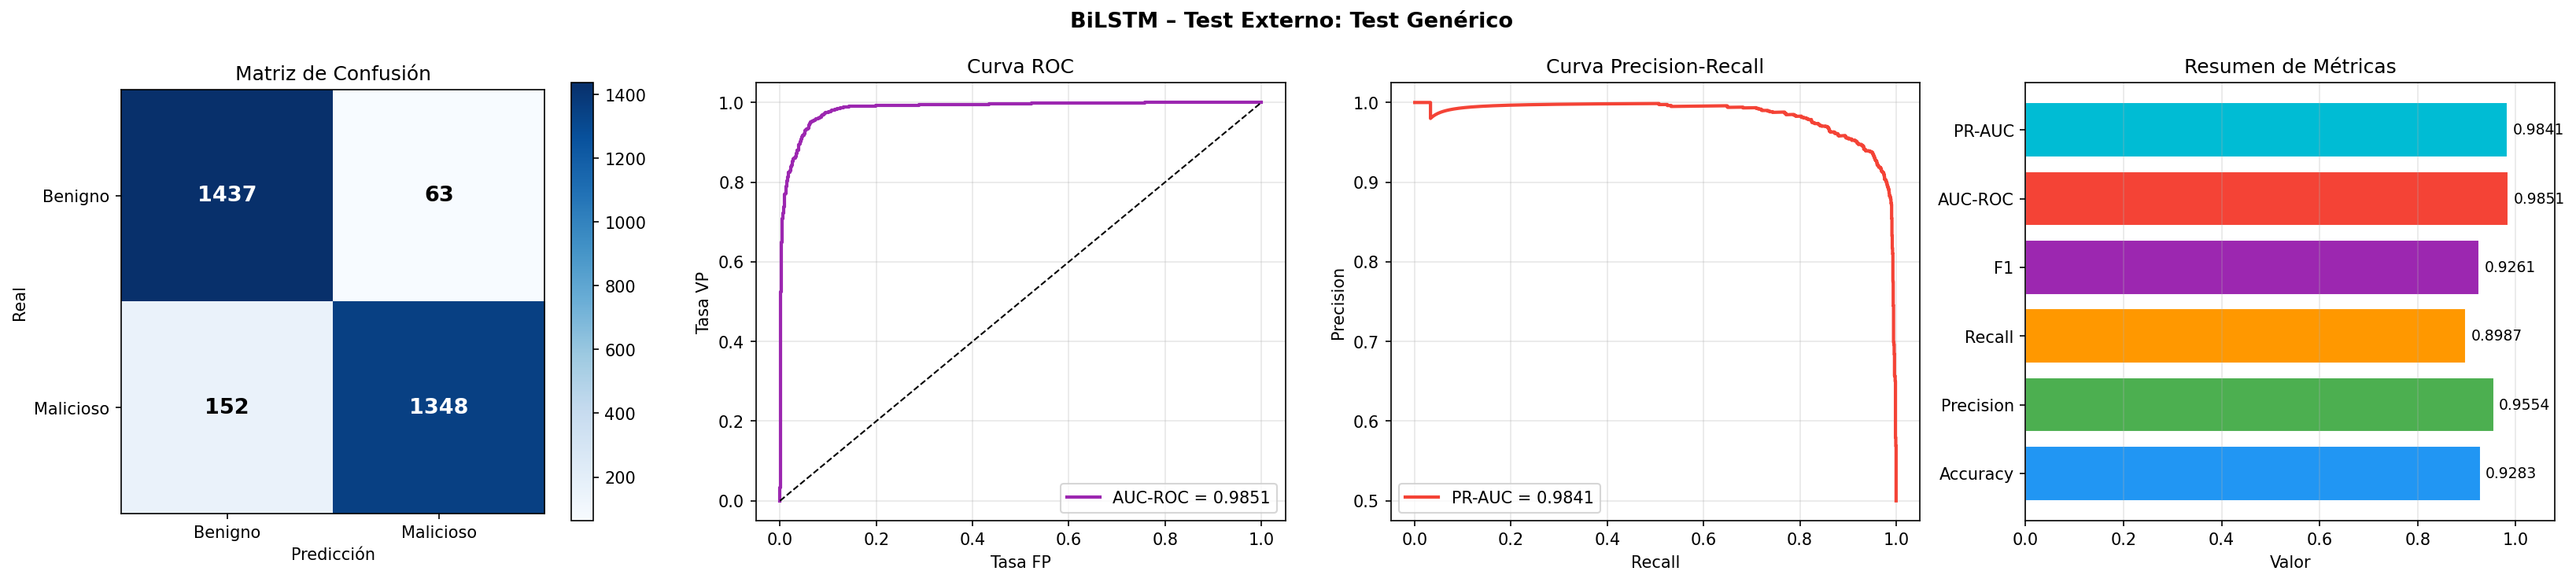


COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico

  Conjunto                       Acc    Prec     Rec      F1   AUC-ROC   PR-AUC
  -----------------------------------------------------------------------------
  Test Interno (15 %)         0.9338  0.9498  0.9160  0.9326    0.9811   0.9829
  Test LATAM (externo)        0.9350  0.9347  0.9353  0.9350    0.9801   0.9831
  Test Genérico (externo)     0.9283  0.9554  0.8987  0.9261    0.9851   0.9841

  ✓ Tabla comparativa guardada: outputs_bilstm/bilstm_comparacion_tests.csv
  ✓ Gráfica comparativa guardada: outputs_bilstm/bilstm_comparacion_tests.png


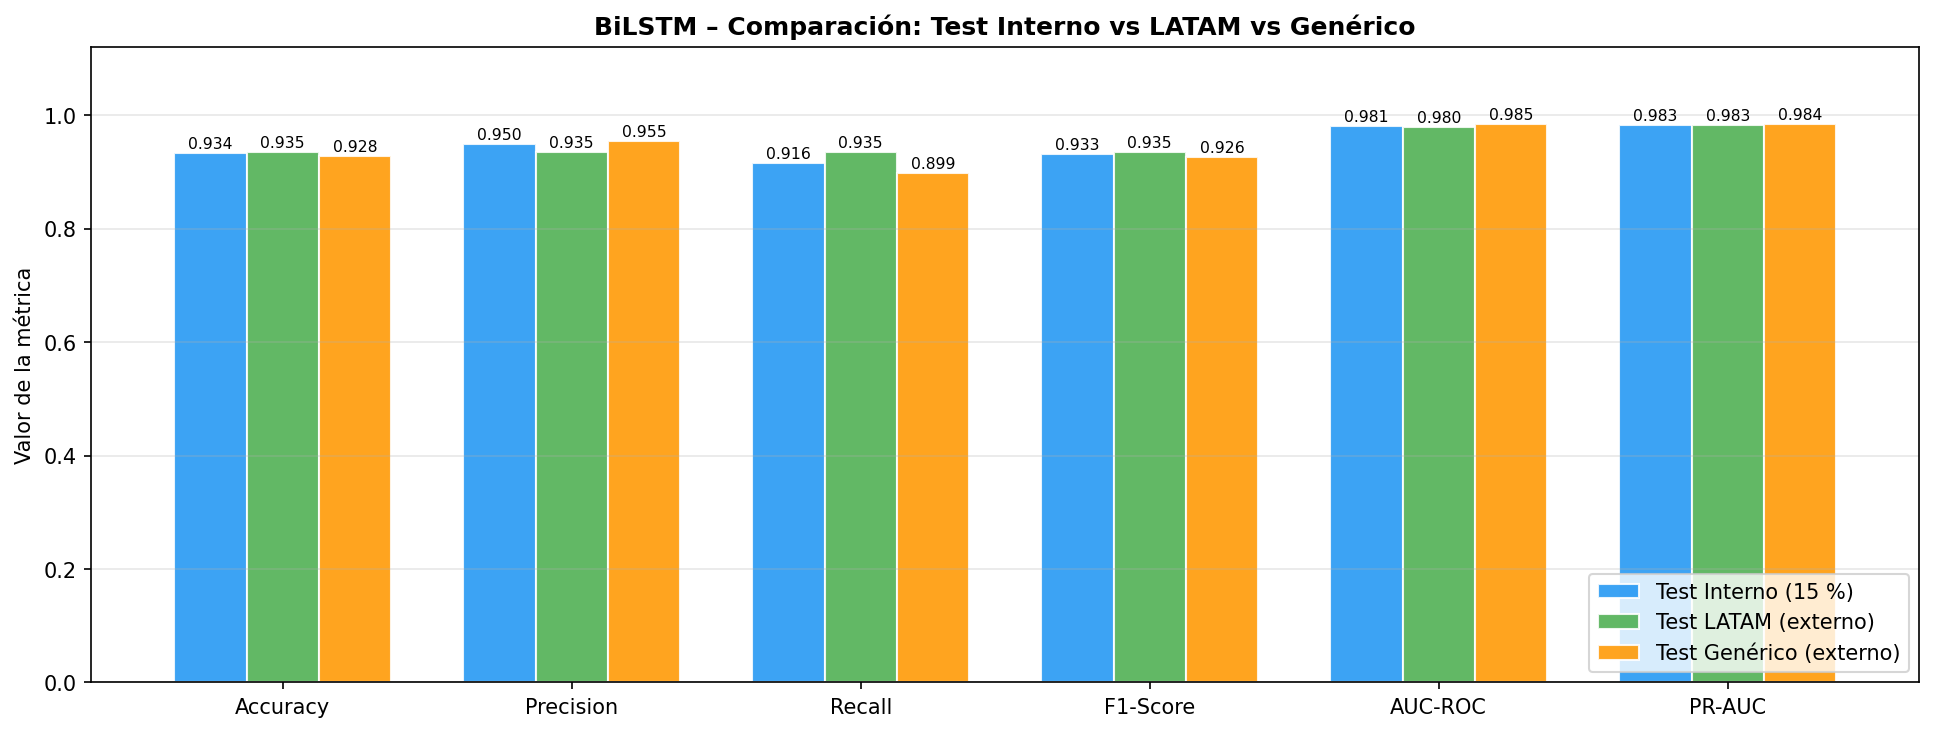


  ✅ Pipeline completo. Todos los resultados en: outputs_bilstm


In [8]:
# =============================================================================
# DETECCIÓN DE URLs MALICIOSAS – BiLSTM (Subashini & Narmatha, 2024)
# Arquitectura: Bidirectional LSTM  |  Optimización: Optuna  |  CV: k=5
# =============================================================================

import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import optuna
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")
from typing import Optional

optuna.logging.set_verbosity(optuna.logging.INFO)

# ---------------------------------------------------------------------------
# CONFIGURACIÓN GENERAL
# ---------------------------------------------------------------------------
SEED       = 42
OUTPUT_DIR = "outputs_bilstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ► Rutas de los tests externos (ajusta si cambian de ubicación)
EXT_BEN_LATAM = "prueba_latam/benigno_latam_1500.csv"
EXT_MAL_LATAM = "prueba_latam/phishing_latam_1500.csv"
EXT_BEN_GEN   = "prueba_generica/benigno_generico_1500.csv"
EXT_MAL_GEN   = "prueba_generica/phishing_generico_1500.csv"

torch.manual_seed(SEED)
np.random.seed(SEED)


# ---------------------------------------------------------------------------
# UTILIDAD: Limpieza de URL (quitar protocolo)
# ---------------------------------------------------------------------------
# Se aplica ANTES de cualquier tokenización, tanto al dataset principal
# como a los tests externos, para garantizar consistencia.
#
# Protocolo eliminado: http://, https://, ftp://, ftps://
# Prefijo eliminado  : www.  (solo si aparece al inicio, tras quitar protocolo)
# ---------------------------------------------------------------------------
_PROTO_RE = re.compile(r'^(?:https?|ftps?)://', re.IGNORECASE)
_WWW_RE   = re.compile(r'^www\.', re.IGNORECASE)

def clean_url(url: str) -> str:
    """
    Elimina el protocolo (http/https/ftp/ftps) y el prefijo 'www.'
    de una URL, dejando solo el host + path + query.

    Ejemplos:
      'https://www.example.com/path' → 'example.com/path'
      'http://phishing.site/login'   → 'phishing.site/login'
      'www.google.com'               → 'google.com'
      'google.com'                   → 'google.com'   (sin cambios)
    """
    url = str(url).strip()
    url = _PROTO_RE.sub('', url)   # quitar protocolo
    url = _WWW_RE.sub('', url)     # quitar www. inicial
    return url


# ---------------------------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Carga del Dataset")
print("=" * 70)

# ► Ajusta esta ruta a tu dataset real
DATA_PATH = "/content/dataset_merged.csv"   # columnas esperadas: url, label, estrato

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["url", "label"]).reset_index(drop=True)
df["url"]   = df["url"].astype(str).str.strip()
df          = df[df["url"].str.len() > 0].reset_index(drop=True)
df["url"]   = df["url"].apply(clean_url)   # mismo pipeline que tests externos
df["label"] = df["label"].astype(int)

# Validar que los labels sean estrictamente binarios {0, 1}
labels_unicos = set(df["label"].unique())
assert labels_unicos <= {0, 1}, (
    f"[ETAPA 1] Labels inesperados en dataset_merged: {labels_unicos}. "
    "Solo se admiten 0 (benigno) y 1 (malicioso)."
)

print(f"  Total muestras : {len(df):,}")
print(f"  Benignas (0)   : {(df['label']==0).sum():,}")
print(f"  Maliciosas (1) : {(df['label']==1).sum():,}")
print(f"  Estratos únicos: {df['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 2. STRATIFIED SPLIT POR ESTRATO
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)")
print("         por estrato")
print("=" * 70)

# Train 70%, Temp 30%
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['estrato']
)
# Val 15%, Test 15%
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['estrato']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"\n  Estratos únicos – Train: {df_train['estrato'].nunique()} "
      f"| Val: {df_val['estrato'].nunique()} | Test: {df_test['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 3. PREPROCESAMIENTO – TOKENIZACIÓN, EMBEDDINGS Y PADDING
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 3 – Tokenización a nivel de carácter, Embeddings y Padding")
print("=" * 70)

# 3.1 Vocabulario de caracteres (construido SOLO con Train)
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

all_chars   = Counter("".join(df_train["url"].values))
vocab_chars = [PAD_TOKEN, UNK_TOKEN] + [ch for ch, _ in all_chars.most_common()]
char2idx    = {ch: idx for idx, ch in enumerate(vocab_chars)}
idx2char    = {idx: ch for ch, idx in char2idx.items()}

VOCAB_SIZE = len(vocab_chars)
PAD_IDX    = char2idx[PAD_TOKEN]
UNK_IDX    = char2idx[UNK_TOKEN]

print(f"  Tamaño de vocabulario de caracteres: {VOCAB_SIZE}")

# 3.2 Longitud máxima (percentil 95 del dataset de entrenamiento)
lengths = df_train["url"].str.len().values
MAX_LEN = int(np.percentile(lengths, 95))
print(f"  Longitud máxima (percentil 95): {MAX_LEN} caracteres")

# 3.3 Función de tokenización
def tokenize(url: str, char2idx: dict, max_len: int,
             pad_idx: int, unk_idx: int) -> list:
    """Convierte una URL en secuencia de índices con padding/truncado."""
    tokens = [char2idx.get(ch, unk_idx) for ch in str(url)[:max_len]]
    tokens += [pad_idx] * (max_len - len(tokens))
    return tokens

# 3.4 Tokenizar splits
print("  Tokenizando splits...")

def tokenize_split(df_split: pd.DataFrame) -> np.ndarray:
    """
    Tokeniza el campo 'url' del DataFrame dado.
    IMPORTANTE: las URLs ya deben llegar limpias (sin protocolo) antes
    de llamar a esta función.
    """
    return np.array([
        tokenize(url, char2idx, MAX_LEN, PAD_IDX, UNK_IDX)
        for url in df_split["url"].values
    ], dtype=np.int32)

X_train = tokenize_split(df_train)
X_val   = tokenize_split(df_val)
X_test  = tokenize_split(df_test)

y_train = df_train["label"].values.astype(np.float32)
y_val   = df_val["label"].values.astype(np.float32)
y_test  = df_test["label"].values.astype(np.float32)

print(f"  X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"  X_val   shape: {X_val.shape}   | y_val   shape: {y_val.shape}")
print(f"  X_test  shape: {X_test.shape}  | y_test  shape: {y_test.shape}")

# 3.5 Guardar CSV de tokens (muestra de 5000 filas para visualización)
SAMPLE_N = min(5000, len(X_train))

token_cols = [f"t{i}" for i in range(MAX_LEN)]
df_tokens  = pd.DataFrame(X_train[:SAMPLE_N], columns=token_cols)
df_tokens.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_tokens.insert(1, "label", df_train["label"].values[:SAMPLE_N])
tokens_path = os.path.join(OUTPUT_DIR, "preprocessing_tokens.csv")
df_tokens.to_csv(tokens_path, index=False)
print(f"\n  ✓ Guardado tokens (muestra): {tokens_path}")

EMB_DIM = 64
np.random.seed(SEED)
emb_matrix     = np.random.randn(VOCAB_SIZE, EMB_DIM).astype(np.float32) * 0.01
url_embeddings = np.array([
    emb_matrix[X_train[i]].mean(axis=0)
    for i in range(SAMPLE_N)
], dtype=np.float32)
emb_cols      = [f"emb_{i}" for i in range(EMB_DIM)]
df_embeddings = pd.DataFrame(url_embeddings, columns=emb_cols)
df_embeddings.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_embeddings.insert(1, "label", df_train["label"].values[:SAMPLE_N])
emb_path = os.path.join(OUTPUT_DIR, "preprocessing_embeddings.csv")
df_embeddings.to_csv(emb_path, index=False)
print(f"  ✓ Guardado embeddings (muestra): {emb_path}")

df_padding = pd.DataFrame({
    "url":              df_train["url"].values[:SAMPLE_N],
    "label":            df_train["label"].values[:SAMPLE_N],
    "url_length":       df_train["url"].str.len().values[:SAMPLE_N],
    "padded_length":    MAX_LEN,
    "truncated":        df_train["url"].str.len().values[:SAMPLE_N] > MAX_LEN,
    "pad_tokens_added": np.maximum(
        0, MAX_LEN - df_train["url"].str.len().values[:SAMPLE_N]
    )
})
padding_path = os.path.join(OUTPUT_DIR, "preprocessing_padding.csv")
df_padding.to_csv(padding_path, index=False)
print(f"  ✓ Guardado padding (muestra): {padding_path}")

print(f"\n  Vocab size        : {VOCAB_SIZE}")
print(f"  Emb dim (default) : {EMB_DIM}")
print(f"  Max length        : {MAX_LEN}")


# ---------------------------------------------------------------------------
# 4. DATASET PyTorch Y DEFINICIÓN DEL MODELO BiLSTM
#    Arquitectura: Subashini & Narmatha (2024) – solo la parte BiLSTM
#    (sin CNN/FRCNN ni Naïve Bayes; embeddings de caracteres + BiLSTM + MLP)
# ---------------------------------------------------------------------------
class URLDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = URLDataset(X_train, y_train)
val_ds   = URLDataset(X_val,   y_val)
test_ds  = URLDataset(X_test,  y_test)


# ─────────────────────────────────────────────────────────────────────────────
# BiLSTM  (Bidirectional Long Short-Term Memory)
#   • Embedding de caracteres  →  BiLSTM  →  concatenación h_forward + h_backward
#   →  Dropout  →  capa densa (clasificador binario)
#
# Cambios respecto al LSTM unidireccional:
#   1. bidirectional=True  en nn.LSTM
#   2. Último estado oculto: concatenación de hn[-2] (forward) y hn[-1] (backward)
#   3. Clasificador recibe hidden_dim * 2 en lugar de hidden_dim
# ─────────────────────────────────────────────────────────────────────────────
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int,
                 num_layers: int, dropout: float, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx
        )
        self.bilstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True          # ← BiLSTM: procesa la URL en ambas direcciones
        )
        self.dropout    = nn.Dropout(dropout)
        # hidden_dim * 2 porque concatenamos el estado forward y el backward
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))                 # (B, L, emb_dim)
        _, (hn, _) = self.bilstm(emb)
        # hn shape: (num_layers * 2, B, hidden_dim)
        # hn[-2] → último estado del forward pass
        # hn[-1] → último estado del backward pass
        last_hidden = torch.cat([hn[-2], hn[-1]], dim=1)      # (B, hidden_dim*2)
        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden).squeeze(1)      # (B,)
        return logits


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Dispositivo de cómputo: {DEVICE}")

import torch.nn.functional as F

class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight
        )


# ---------------------------------------------------------------------------
# Helper: run_epoch
# ---------------------------------------------------------------------------
def run_epoch(loader, model, criterion, optimizer, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == y_batch.long()).sum().item()
            total      += len(y_batch)

    if total == 0:
        return 0.0, 0.0
    return total_loss / total, correct / total


def generalization_score(tr_loss: float, vl_loss: float,
                         tr_acc: float, vl_acc: float,
                         w_loss: float = 1.0, w_acc: float = 0.5) -> float:
    """
    Métrica compuesta (menor = mejor) para elegir el checkpoint con menos
    sobreajuste. Penaliza cuando train supera claramente a val en loss o acc.
    """
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)
    return vl_loss + w_loss * loss_gap + w_acc * acc_gap


# ---------------------------------------------------------------------------
# 5. BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 4 – Búsqueda de Hiperparámetros con Optuna")
print("=" * 70)

def objective(trial):
    hidden_dim   = trial.suggest_categorical("hidden_dim",   [64, 128, 256])
    num_layers   = trial.suggest_int("num_layers", 1, 3)
    dropout      = trial.suggest_float("dropout",  0.3, 0.6)
    lr           = trial.suggest_float("lr",       1e-4, 1e-2, log=True)
    emb_dim      = trial.suggest_categorical("emb_dim",      [32, 64, 128])
    batch_size   = trial.suggest_categorical("batch_size",   [32, 64, 128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)

    train_loader_opt = DataLoader(train_ds, batch_size=batch_size,
                                  shuffle=True,  num_workers=0, pin_memory=True)
    val_loader_opt   = DataLoader(val_ds,   batch_size=batch_size,
                                  shuffle=False, num_workers=0, pin_memory=True)

    model_opt = BiLSTMModel(
        vocab_size=VOCAB_SIZE, emb_dim=emb_dim,
        hidden_dim=hidden_dim, num_layers=num_layers,
        dropout=dropout, pad_idx=PAD_IDX
    ).to(DEVICE)

    criterion_opt = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_opt = torch.optim.Adam(model_opt.parameters(),
                                     lr=lr, weight_decay=weight_decay)

    for epoch in range(10):
        model_opt.train()
        for X_batch, y_batch in train_loader_opt:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer_opt.zero_grad()
            loss = criterion_opt(model_opt(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model_opt.parameters(), max_norm=5.0)
            optimizer_opt.step()

        model_opt.eval()
        val_loss, n_samples = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_opt:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                loss      = criterion_opt(model_opt(X_batch), y_batch)
                val_loss += loss.item() * len(y_batch)
                n_samples += len(y_batch)

        val_loss /= n_samples
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
print("Iniciando optimización con Optuna (50 trials)...")
study.optimize(objective, n_trials=50)

print("\n🏆 Mejores hiperparámetros encontrados:")
best_params = study.best_params
for k, v in best_params.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------------
# 6. ENTRENAMIENTO FINAL CON MEJORES PARÁMETROS
#    (70 % Train | 15 % Val para monitoreo | 15 % Test)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)")
print("=" * 70)

MAX_EPOCHS_FINAL = 50
PATIENCE_ES      = 5          # parar antes si la generalización no mejora
MIN_DELTA_GEN    = 1e-4       # mejora mínima en score de generalización
GAP_LOSS_WEIGHT  = 1.0       # peso brecha val_loss - train_loss
GAP_ACC_WEIGHT   = 0.5        # peso brecha train_acc - val_acc

X_final = tokenize_split(df_train)
y_final = df_train["label"].values.astype(np.float32)

final_ds = URLDataset(X_final, y_final)

BEST_BATCH         = best_params["batch_size"]
final_loader       = DataLoader(final_ds, batch_size=BEST_BATCH,
                                shuffle=True,  num_workers=2, pin_memory=True)
val_monitor_loader = DataLoader(val_ds,   batch_size=BEST_BATCH,
                                shuffle=False, num_workers=2, pin_memory=True)
test_loader        = DataLoader(test_ds,  batch_size=BEST_BATCH,
                                shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"  Épocas máx: {MAX_EPOCHS_FINAL}")
print(f"  Checkpoint: score generalización (val_loss + gap train-val)")
print(f"  EarlyStopping: patience={PATIENCE_ES}, min_delta={MIN_DELTA_GEN}")

# Modelo BiLSTM con best_params
best_model = BiLSTMModel(
    vocab_size=VOCAB_SIZE,
    emb_dim=best_params["emb_dim"],
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    pad_idx=PAD_IDX
).to(DEVICE)

# Ponderación positiva para mitigar desbalance (sin tocar el split)
pos = float((y_final == 1).sum())
neg = float((y_final == 0).sum())
pos_weight = None
if pos > 0 and neg > 0:
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
    print(f"  pos_weight (neg/pos): {pos_weight.item():.4f}")

criterion = SmoothBCEWithLogitsLoss(smoothing=0.05, pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

# Reduce LR cuando la validación se estanca (ayuda a generalizar)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5, min_lr=1e-6
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "gen_score":  [], "loss_gap": [], "acc_gap":  [],
}

t0 = time.time()
best_gen_score   = float("inf")
best_val_loss    = float("inf")
best_state       = None
best_epoch       = 0
best_val_epoch   = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    tr_loss, tr_acc = run_epoch(final_loader,       best_model, criterion,
                                optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_monitor_loader, best_model, criterion,
                                optimizer, train=False)

    gen_score = generalization_score(
        tr_loss, vl_loss, tr_acc, vl_acc,
        w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
    )
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["gen_score"].append(gen_score)
    history["loss_gap"].append(loss_gap)
    history["acc_gap"].append(acc_gap)

    scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_val_epoch = epoch

    # Checkpoint: menor sobreajuste (no solo menor val_loss)
    if gen_score < best_gen_score - MIN_DELTA_GEN:
        best_gen_score = gen_score
        best_epoch     = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in best_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        marker = " *" if epoch == best_epoch else ""
        print(f"  Época {epoch:3d}/{MAX_EPOCHS_FINAL}{marker} | "
              f"Loss → Train: {tr_loss:.4f}  Val: {vl_loss:.4f} | "
              f"Acc  → Train: {tr_acc:.4f}  Val: {vl_acc:.4f} | "
              f"Gen: {gen_score:.4f} (gap L/A: {loss_gap:.4f}/{acc_gap:.4f}) | "
              f"LR: {current_lr:.2e} | Tiempo: {elapsed:.1f}s")

    if patience_counter >= PATIENCE_ES:
        print(f"  ⏹ EarlyStopping en época {epoch} "
              f"(mejor generalización: época {best_epoch}, gen={best_gen_score:.4f}).")
        break

# Restaurar checkpoint con mejor equilibrio train/val
if best_state is not None:
    best_model.load_state_dict(best_state)

model_path = os.path.join(OUTPUT_DIR, "bilstm_best_optuna_model.pt")
torch.save({k: v.cpu().clone() for k, v in best_model.state_dict().items()}, model_path)

idx = best_epoch - 1
print(f"\n  ✓ Entrenamiento completado")
print(f"  ✓ Época guardada (menor sobreajuste): {best_epoch}")
print(f"      Train loss/acc: {history['train_loss'][idx]:.4f} / {history['train_acc'][idx]:.4f}")
print(f"      Val   loss/acc: {history['val_loss'][idx]:.4f} / {history['val_acc'][idx]:.4f}")
print(f"      Gen score: {best_gen_score:.4f} | gap loss: {history['loss_gap'][idx]:.4f} | "
      f"gap acc: {history['acc_gap'][idx]:.4f}")
if best_val_epoch != best_epoch:
    j = best_val_epoch - 1
    print(f"  ℹ Época con menor val_loss pura: {best_val_epoch} "
          f"(val_loss={history['val_loss'][j]:.4f}, "
          f"train_acc-val_acc={history['acc_gap'][j]:.4f}) — no seleccionada por overfitting")
print(f"  ✓ Modelo guardado en: {model_path}")


# ---------------------------------------------------------------------------
# 7. CROSS-VALIDATION (k=5) CON best_params
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5.5 – Cross-Validation (k=5) con best_params")
print("=" * 70)

df_cv = pd.concat([df_train, df_val], ignore_index=True)
X_cv  = tokenize_split(df_cv)
y_cv  = df_cv["label"].values.astype(np.float32)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_cv, df_cv['estrato']), 1):

    X_tr_fold  = X_cv[train_idx];   y_tr_fold  = y_cv[train_idx]
    X_val_fold = X_cv[val_idx];     y_val_fold = y_cv[val_idx]

    tr_ds_fold  = URLDataset(X_tr_fold,  y_tr_fold)
    val_ds_fold = URLDataset(X_val_fold, y_val_fold)

    tr_loader_fold  = DataLoader(tr_ds_fold,  batch_size=BEST_BATCH,
                                 shuffle=True,  num_workers=2, pin_memory=True)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=BEST_BATCH,
                                 shuffle=False, num_workers=2, pin_memory=True)

    model_cv = BiLSTMModel(
        vocab_size=VOCAB_SIZE,
        emb_dim=best_params["emb_dim"],
        hidden_dim=best_params["hidden_dim"],
        num_layers=best_params["num_layers"],
        dropout=best_params["dropout"],
        pad_idx=PAD_IDX
    ).to(DEVICE)

    criterion_cv = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_cv = torch.optim.Adam(
        model_cv.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )
    scheduler_cv = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode="min", patience=3, factor=0.3, min_lr=1e-6
    )

    best_cv_gen         = float("inf")
    best_cv_state       = None
    cv_patience_counter = 0
    stop_epoch          = MAX_EPOCHS_FINAL

    for epoch in range(1, MAX_EPOCHS_FINAL + 1):
        # Warmup lineal de 3 épocas para cross-validation
        if epoch <= 3:
            warmup_factor = epoch / 3.0
            current_lr = best_params["lr"] * warmup_factor
            for param_group in optimizer_cv.param_groups:
                param_group['lr'] = current_lr

        tr_loss_cv, tr_acc_cv = run_epoch(tr_loader_fold,  model_cv, criterion_cv,
                                          optimizer_cv, train=True)
        vl_loss_cv, vl_acc_cv = run_epoch(val_loader_fold, model_cv, criterion_cv,
                                          optimizer_cv, train=False)

        # Solo activar el scheduler después del warmup
        if epoch > 3:
            scheduler_cv.step(vl_loss_cv)

        gen_cv = generalization_score(
            tr_loss_cv, vl_loss_cv, tr_acc_cv, vl_acc_cv,
            w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
        )

        if gen_cv < best_cv_gen - MIN_DELTA_GEN:
            best_cv_gen           = gen_cv
            best_cv_state         = {k: v.cpu().clone()
                                     for k, v in model_cv.state_dict().items()}
            cv_patience_counter   = 0
        else:
            cv_patience_counter += 1

        if cv_patience_counter >= PATIENCE_ES:
            stop_epoch = epoch
            break

    if best_cv_state is not None:
        model_cv.load_state_dict(best_cv_state)
    model_cv.eval()

    fold_logits, fold_preds, fold_labels = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_fold:
            X_b    = X_b.to(DEVICE)
            logits = model_cv(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            fold_logits.extend(probs.tolist())
            fold_preds.extend(preds.tolist())
            fold_labels.extend(y_b.numpy().tolist())

    y_t       = np.array(fold_labels, dtype=int)
    y_p       = np.array(fold_preds,  dtype=int)
    y_prob_cv = np.array(fold_logits)

    f_acc  = accuracy_score(y_t, y_p)
    f_prec = precision_score(y_t, y_p, zero_division=0)
    f_rec  = recall_score(y_t, y_p,    zero_division=0)
    f_f1   = f1_score(y_t, y_p,        zero_division=0)
    f_roc  = roc_auc_score(y_t, y_prob_cv)
    f_pr   = average_precision_score(y_t, y_prob_cv)

    cv_results.append({
        "fold": fold, "Accuracy": f_acc, "Precision": f_prec,
        "Recall": f_rec, "F1": f_f1, "AUC_ROC": f_roc, "PR_AUC": f_pr
    })

    print(f"  Fold {fold}/5 | F1: {f_f1:.4f} | AUC-ROC: {f_roc:.4f} "
          f"| Época stop: {stop_epoch}")

cv_df       = pd.DataFrame(cv_results)
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
cv_mean     = cv_df[metric_keys].mean()
cv_std      = cv_df[metric_keys].std()

label_map = {
    "Accuracy":  "Accuracy",
    "Precision": "Precision",
    "Recall":    "Recall",
    "F1":        "F1-Score",
    "AUC_ROC":   "AUC-ROC",
    "PR_AUC":    "PR-AUC",
}

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤""")
for key in metric_keys:
    print(f"  │ {label_map[key]:<24s} │   {cv_mean[key]:.4f}     │  ±{cv_std[key]:.4f}       │")
print("  └──────────────────────────┴──────────────┴───────────────┘")

cv_export = cv_df.copy()
mean_row  = {col: (cv_mean[col] if col in metric_keys else "mean") for col in cv_export.columns}
std_row   = {col: (cv_std[col]  if col in metric_keys else "std")  for col in cv_export.columns}
cv_export = pd.concat(
    [cv_export, pd.DataFrame([mean_row]), pd.DataFrame([std_row])],
    ignore_index=True
)
cv_path = os.path.join(OUTPUT_DIR, "bilstm_cv_results.csv")
cv_export.to_csv(cv_path, index=False)
print(f"\n  ✓ Guardado CV results: {cv_path}")


# ---------------------------------------------------------------------------
# 8. EVALUACIÓN EN TEST SET
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 6 – Evaluación en Test Set")
print("=" * 70)

best_model.eval()
all_logits, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = best_model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        all_logits.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.numpy().tolist())

y_true  = np.array(all_labels, dtype=int)
y_pred  = np.array(all_preds,  dtype=int)
y_prob  = np.array(all_logits)

acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred,  zero_division=0)
rec     = recall_score(y_true, y_pred,     zero_division=0)
f1      = f1_score(y_true, y_pred,         zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
cm      = confusion_matrix(y_true, y_pred)

print(f"""
  ┌─────────────────────────────────────────────┐
  │        MÉTRICAS DE EVALUACIÓN – BiLSTM      │
  ├──────────────────────────┬──────────────────┤
  │  Exactitud (Accuracy)    │  {acc:.4f}          │
  │  Precisión (Precision)   │  {prec:.4f}          │
  │  Exhaustividad (Recall)  │  {rec:.4f}          │
  │  F1-Score                │  {f1:.4f}          │
  │  AUC-ROC                 │  {roc_auc:.4f}          │
  │  PR-AUC                  │  {pr_auc:.4f}          │
  └──────────────────────────┴──────────────────┘
""")

print("  Matriz de Confusión:")
print(f"              Pred 0  Pred 1")
print(f"  Real 0  :   {cm[0,0]:6d}  {cm[0,1]:6d}   (TN / FP)")
print(f"  Real 1  :   {cm[1,0]:6d}  {cm[1,1]:6d}   (FN / TP)")
print("\n  Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["Benigno", "Malicioso"]))


# ---------------------------------------------------------------------------
# 9. GUARDAR MÉTRICAS Y GRÁFICAS
# ---------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Modelo":    ["BiLSTM"],
    "Best_Epoch": [best_epoch],
    "Accuracy":  [round(acc,     4)],
    "Precision": [round(prec,    4)],
    "Recall":    [round(rec,     4)],
    "F1_Score":  [round(f1,      4)],
    "AUC_ROC":   [round(roc_auc, 4)],
    "PR_AUC":    [round(pr_auc,  4)],
    "TN": [cm[0,0]], "FP": [cm[0,1]],
    "FN": [cm[1,0]], "TP": [cm[1,1]],
})
metrics_path = os.path.join(OUTPUT_DIR, "bilstm_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

history_df = pd.DataFrame(history)
history_df.index.name = "epoch"
history_path = os.path.join(OUTPUT_DIR, "bilstm_training_history.csv")
history_df.to_csv(history_path)

epochs_ran = len(history["train_loss"])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "BiLSTM – Detección de URLs Maliciosas (Optimizado con Optuna)",
    fontsize=14, fontweight="bold"
)

# Pérdida BCE (Train vs Val)
ax = axes[0, 0]
ax.plot(ep_range, history["train_loss"], label="Train Loss", color="#2196F3")
ax.plot(ep_range, history["val_loss"],   label="Val Loss",   color="#FF9800")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Función de Pérdida BCE (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy (Train vs Val)
ax = axes[0, 1]
ax.plot(ep_range, history["train_acc"], label="Train Acc", color="#4CAF50")
ax.plot(ep_range, history["val_acc"],   label="Val Acc",   color="#F44336")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Exactitud por Época (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)

# Matriz de confusión
ax = axes[0, 2]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight="bold")
ax.set_title("Matriz de Confusión (Test)")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

# Curva ROC
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color="#9C27B0", lw=2, label=f"AUC-ROC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(); ax.grid(True, alpha=0.3)

# Curva Precision-Recall
ax = axes[1, 1]
prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
ax.plot(rec_c, prec_c, color="#F44336", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True, alpha=0.3)

# Tabla resumen métricas (Test + CV mean±std)
ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Métrica",    "Test",           "CV Mean ± Std"],
    ["Accuracy",   f"{acc:.4f}",     f"{cv_mean['Accuracy']:.4f} ± {cv_std['Accuracy']:.4f}"],
    ["Precision",  f"{prec:.4f}",    f"{cv_mean['Precision']:.4f} ± {cv_std['Precision']:.4f}"],
    ["Recall",     f"{rec:.4f}",     f"{cv_mean['Recall']:.4f} ± {cv_std['Recall']:.4f}"],
    ["F1-Score",   f"{f1:.4f}",      f"{cv_mean['F1']:.4f} ± {cv_std['F1']:.4f}"],
    ["AUC-ROC",    f"{roc_auc:.4f}", f"{cv_mean['AUC_ROC']:.4f} ± {cv_std['AUC_ROC']:.4f}"],
    ["PR-AUC",     f"{pr_auc:.4f}",  f"{cv_mean['PR_AUC']:.4f} ± {cv_std['PR_AUC']:.4f}"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.6, 2.2)
ax.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "bilstm_results_optuna.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"\n  Pipeline completado (test interno). Resultados guardados en: {OUTPUT_DIR}")
display(Image(plot_path))


# ---------------------------------------------------------------------------
# 10. TESTS EXTERNOS
#     · Test LATAM    : benignos_test_latam_3000    + phishing_test_latam_3000
#     · Test Genérico : benignos_test_generico_3000 + phishing_test_generico_3000
#
#  PREPROCESAMIENTO PREVIO A LA TOKENIZACIÓN:
#   1. Se normaliza el nombre de la columna URL (acepta 'url' o 'URL').
#   2. Se asigna label=0 a los benignos y label=1 a los maliciosos
#      (la asignación es explícita e independiente del contenido del CSV).
#   3. Se aplica clean_url() → elimina protocolo y www. de cada URL
#      usando el MISMO regex que se usó para el dataset de entrenamiento.
#   4. Solo entonces se tokeniza con el vocabulario construido sobre Train.
# ---------------------------------------------------------------------------

def load_external_set(path_ben: str, path_mal: str, nombre: str) -> pd.DataFrame:
    """
    Carga los CSV benignos (label=0) y maliciosos (label=1),
    normaliza el nombre de columna, asigna labels correctos,
    y aplica clean_url() antes de devolver el DataFrame.

    Pasos internos
    --------------
    1. Leer CSV y normalizar nombres de columna a minúsculas + strip.
    2. Verificar que exista la columna 'url'; lanzar error descriptivo si no.
    3. Asignar label=0 a todos los benignos y label=1 a todos los maliciosos
       (no se confía en ninguna columna 'label' preexistente en los CSVs externos).
    4. Eliminar filas con URL nula o vacía.
    5. Aplicar clean_url(): quitar protocolo y www. para que el vocabulario
       de Train reconozca los tokens correctamente.
    6. Imprimir resumen de limpieza de protocolos.
    """
    df_b = pd.read_csv(path_ben)
    df_m = pd.read_csv(path_mal)

    # ── Paso 1: normalizar nombres de columna ───────────────────────────────
    for d in [df_b, df_m]:
        d.columns = [c.strip().lower() for c in d.columns]

    # ── Paso 2: verificar que exista columna 'url' ──────────────────────────
    for d, path in [(df_b, path_ben), (df_m, path_mal)]:
        if "url" not in d.columns:
            raise ValueError(
                f"[{nombre}] No se encontró columna 'url' en '{path}'.\n"
                f"  Columnas disponibles: {d.columns.tolist()}"
            )

    # ── Paso 3: seleccionar solo 'url' y asignar label explícitamente ───────
    #    (ignoramos cualquier columna 'label' que pueda traer el CSV externo)
    df_b = df_b[["url"]].copy()
    df_m = df_m[["url"]].copy()
    df_b["label"] = 0   # benigno
    df_m["label"] = 1   # malicioso / phishing

    # ── Paso 4: eliminar filas nulas/vacías ─────────────────────────────────
    df_ext = pd.concat([df_b, df_m], ignore_index=True)
    df_ext["url"] = df_ext["url"].astype(str).str.strip()
    antes = len(df_ext)
    df_ext = df_ext[df_ext["url"].str.len() > 0].reset_index(drop=True)
    if antes - len(df_ext) > 0:
        print(f"  [{nombre}] ⚠  Se eliminaron {antes - len(df_ext)} filas con URL vacía.")

    # ── Paso 5: limpiar protocolos ANTES de tokenizar (igual que train) ────
    urls_originales = df_ext["url"].copy()
    df_ext["url"]   = df_ext["url"].apply(clean_url)

    # ── Paso 5b: auditoría rápida (unicidad, espacios) ───────────────────────
    n_cambiadas = (urls_originales != df_ext["url"]).sum()
    n_ws = urls_originales.str.contains(r"\s", regex=True).sum()
    if n_ws:
        print(f"  [{nombre}] ⚠  URLs con espacios antes de strip: {n_ws}")

    n_dup = df_ext["url"].duplicated().sum()
    if n_dup:
        print(f"  [{nombre}] ⚠  URLs duplicadas tras clean_url: {n_dup} "
              f"(se conserva la primera ocurrencia)")
        df_ext = df_ext.drop_duplicates(subset=["url"], keep="first").reset_index(drop=True)

    # ── Paso 6: informe de limpieza ─────────────────────────────────────────
    print(f"  [{nombre}] URLs con protocolo / www. eliminado: "
          f"{n_cambiadas:,} de {len(df_ext):,} "
          f"({n_cambiadas/len(df_ext)*100:.1f} %)")
    print(f"  [{nombre}] URLs únicas finales: {df_ext['url'].nunique():,} / {len(df_ext):,}")

    # ── Validación final de labels ───────────────────────────────────────────
    assert set(df_ext["label"].unique()) <= {0, 1}, (
        f"[{nombre}] Error interno: labels inesperados tras asignación."
    )
    assert (df_ext["label"] == 0).sum() > 0, (
        f"[{nombre}] Error: no hay muestras benignas (label=0)."
    )
    assert (df_ext["label"] == 1).sum() > 0, (
        f"[{nombre}] Error: no hay muestras maliciosas (label=1)."
    )

    return df_ext


def evaluar_externo(df_ext: pd.DataFrame, nombre: str, tag: str) -> dict:
    """
    Tokeniza con el vocab de Train, crea DataLoader y evalúa best_model.
    Devuelve dict con métricas y guarda CSV + gráfica.

    NOTA: df_ext ya llega con protocolo quitado (lo hace load_external_set).
    """
    print(f"\n{'='*70}")
    print(f"  Test Externo – {nombre}")
    print(f"  Muestras: {len(df_ext):,}  |  "
          f"Benignas (0): {(df_ext['label']==0).sum():,}  |  "
          f"Maliciosas (1): {(df_ext['label']==1).sum():,}")
    print(f"{'='*70}")

    # tokenize_split: mismo vocab/MAX_LEN/PAD/UNK que train (definidos en ETAPA 3)
    n_trunc = (df_ext["url"].str.len() > MAX_LEN).sum()
    if n_trunc:
        pct = n_trunc / len(df_ext) * 100
        print(f"  [{nombre}] ⚠  {n_trunc:,} URLs ({pct:.1f}%) superan MAX_LEN={MAX_LEN} "
              f"(se truncan como en train, percentil 95)")

    X_ext = tokenize_split(df_ext)
    y_ext = df_ext["label"].values.astype(np.float32)

    ext_ds     = URLDataset(X_ext, y_ext)
    ext_loader = DataLoader(ext_ds, batch_size=BEST_BATCH,
                            shuffle=False, num_workers=2, pin_memory=True)

    best_model.eval()
    ext_logits, ext_preds, ext_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in ext_loader:
            X_batch = X_batch.to(DEVICE)
            logits  = best_model(X_batch)
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs >= 0.5).astype(int)
            ext_logits.extend(probs.tolist())
            ext_preds.extend(preds.tolist())
            ext_labels.extend(y_batch.numpy().tolist())

    yt    = np.array(ext_labels, dtype=int)
    yp    = np.array(ext_preds,  dtype=int)
    yprob = np.array(ext_logits)

    e_acc  = accuracy_score(yt, yp)
    e_prec = precision_score(yt, yp, zero_division=0)
    e_rec  = recall_score(yt, yp,    zero_division=0)
    e_f1   = f1_score(yt, yp,        zero_division=0)
    e_roc  = roc_auc_score(yt, yprob)
    e_pr   = average_precision_score(yt, yprob)
    e_cm   = confusion_matrix(yt, yp)

    print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – {nombre:<43s}│
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  {e_acc:.4f}                      │
  │  Precisión (Precision)   │  {e_prec:.4f}                      │
  │  Exhaustividad (Recall)  │  {e_rec:.4f}                      │
  │  F1-Score                │  {e_f1:.4f}                      │
  │  AUC-ROC                 │  {e_roc:.4f}                      │
  │  PR-AUC                  │  {e_pr:.4f}                      │
  └──────────────────────────┴───────────────────────────────┘
""")

    print("  Matriz de Confusión:")
    print(f"              Pred 0  Pred 1")
    print(f"  Real 0  :   {e_cm[0,0]:6d}  {e_cm[0,1]:6d}   (TN / FP)")
    print(f"  Real 1  :   {e_cm[1,0]:6d}  {e_cm[1,1]:6d}   (FN / TP)")
    print("\n  Reporte de Clasificación:")
    print(classification_report(yt, yp, target_names=["Benigno", "Malicioso"]))

    # ── CSV métricas ──────────────────────────────────────────────────────
    metrics_ext = pd.DataFrame({
        "Modelo":    [f"BiLSTM_{tag}"],
        "Accuracy":  [round(e_acc,  4)],
        "Precision": [round(e_prec, 4)],
        "Recall":    [round(e_rec,  4)],
        "F1_Score":  [round(e_f1,   4)],
        "AUC_ROC":   [round(e_roc,  4)],
        "PR_AUC":    [round(e_pr,   4)],
        "TN": [e_cm[0,0]], "FP": [e_cm[0,1]],
        "FN": [e_cm[1,0]], "TP": [e_cm[1,1]],
    })
    csv_path = os.path.join(OUTPUT_DIR, f"bilstm_metrics_ext_{tag}.csv")
    metrics_ext.to_csv(csv_path, index=False)
    print(f"  ✓ Métricas guardadas: {csv_path}")

    # ── Gráfica (4 subplots: CM, ROC, PR, barra métricas) ────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"BiLSTM – Test Externo: {nombre}",
        fontsize=13, fontweight="bold"
    )

    # Matriz de confusión
    ax = axes[0]
    im = ax.imshow(e_cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
    thresh = e_cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(e_cm[i, j]), ha="center", va="center",
                    color="white" if e_cm[i, j] > thresh else "black",
                    fontsize=13, fontweight="bold")
    ax.set_title("Matriz de Confusión")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

    # Curva ROC
    ax = axes[1]
    fpr_e, tpr_e, _ = roc_curve(yt, yprob)
    ax.plot(fpr_e, tpr_e, color="#9C27B0", lw=2,
            label=f"AUC-ROC = {e_roc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("Curva ROC")
    ax.set_xlabel("Tasa FP"); ax.set_ylabel("Tasa VP")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Curva Precision-Recall
    ax = axes[2]
    prec_e, rec_e, _ = precision_recall_curve(yt, yprob)
    ax.plot(rec_e, prec_e, color="#F44336", lw=2,
            label=f"PR-AUC = {e_pr:.4f}")
    ax.set_title("Curva Precision-Recall")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Barra de métricas
    ax = axes[3]
    met_names = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
    met_vals  = [e_acc, e_prec, e_rec, e_f1, e_roc, e_pr]
    colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]
    bars = ax.barh(met_names, met_vals, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.08)
    for bar, val in zip(bars, met_vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title("Resumen de Métricas")
    ax.set_xlabel("Valor")
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    png_path = os.path.join(OUTPUT_DIR, f"bilstm_results_ext_{tag}.png")
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✓ Gráfica guardada:  {png_path}")
    display(Image(png_path))

    return {
        "nombre": nombre, "tag": tag,
        "Accuracy": e_acc, "Precision": e_prec, "Recall": e_rec,
        "F1": e_f1, "AUC_ROC": e_roc, "PR_AUC": e_pr,
        "TN": e_cm[0,0], "FP": e_cm[0,1],
        "FN": e_cm[1,0], "TP": e_cm[1,1],
    }


# ── Etapa 10a: Test Externo LATAM ─────────────────────────────────────────
print("\n" + "=" * 70)
print("ETAPA 7a – Test Externo LATAM")
print("=" * 70)

df_ext_latam = load_external_set(EXT_BEN_LATAM, EXT_MAL_LATAM, "LATAM")
res_latam    = evaluar_externo(df_ext_latam, "Test LATAM", "latam")


# ── Etapa 10b: Test Externo Genérico ──────────────────────────────────────
print("\n" + "=" * 70)
print("ETAPA 7b – Test Externo Genérico")
print("=" * 70)

df_ext_gen = load_external_set(EXT_BEN_GEN, EXT_MAL_GEN, "Genérico")
res_gen    = evaluar_externo(df_ext_gen, "Test Genérico", "generico")


# ── Tabla comparativa final: Test Interno vs LATAM vs Genérico ────────────
print("\n" + "=" * 70)
print("COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico")
print("=" * 70)

comp_df = pd.DataFrame([
    {
        "Conjunto":  "Test Interno (15 %)",
        "Accuracy":  round(acc,     4),
        "Precision": round(prec,    4),
        "Recall":    round(rec,     4),
        "F1":        round(f1,      4),
        "AUC_ROC":   round(roc_auc, 4),
        "PR_AUC":    round(pr_auc,  4),
    },
    {
        "Conjunto":  "Test LATAM (externo)",
        "Accuracy":  round(res_latam["Accuracy"],  4),
        "Precision": round(res_latam["Precision"], 4),
        "Recall":    round(res_latam["Recall"],    4),
        "F1":        round(res_latam["F1"],        4),
        "AUC_ROC":   round(res_latam["AUC_ROC"],   4),
        "PR_AUC":    round(res_latam["PR_AUC"],    4),
    },
    {
        "Conjunto":  "Test Genérico (externo)",
        "Accuracy":  round(res_gen["Accuracy"],  4),
        "Precision": round(res_gen["Precision"], 4),
        "Recall":    round(res_gen["Recall"],    4),
        "F1":        round(res_gen["F1"],        4),
        "AUC_ROC":   round(res_gen["AUC_ROC"],   4),
        "PR_AUC":    round(res_gen["PR_AUC"],    4),
    },
])

# Imprimir tabla en consola
header = f"{'Conjunto':<26} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC-ROC':>9} {'PR-AUC':>8}"
print(f"\n  {header}")
print("  " + "-" * len(header))
for _, row in comp_df.iterrows():
    print(f"  {row['Conjunto']:<26} "
          f"{row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} "
          f"{row['AUC_ROC']:>9.4f} {row['PR_AUC']:>8.4f}")

# Guardar CSV comparativo
comp_path = os.path.join(OUTPUT_DIR, "bilstm_comparacion_tests.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\n  ✓ Tabla comparativa guardada: {comp_path}")

# Gráfica comparativa de barras agrupadas
fig, ax = plt.subplots(figsize=(13, 5))
metricas_comp = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
labels_comp   = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "PR-AUC"]
x      = np.arange(len(metricas_comp))
width  = 0.25
colores_comp = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i * width, vals, width,
                  label=row["Conjunto"], color=colores_comp[i],
                  edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_comp)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("BiLSTM – Comparación: Test Interno vs LATAM vs Genérico",
             fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
comp_plot_path = os.path.join(OUTPUT_DIR, "bilstm_comparacion_tests.png")
plt.savefig(comp_plot_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"  ✓ Gráfica comparativa guardada: {comp_plot_path}")
display(Image(comp_plot_path))

print(f"\n  ✅ Pipeline completo. Todos los resultados en: {OUTPUT_DIR}")

In [3]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Image, display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
OUTPUT_DIR = "/content/"

BENIGN_PATH    = "master_generico/benigno_generico_50k.csv"
MALICIOUS_PATH = "master_generico/phishing_generico_50k.csv"

# ---------------------------------------------------------------------------
# 1. UNIÓN DE DATASETS Y CREACIÓN DE ESTRATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Unión de datasets y clasificación")
print("=" * 70)

benign = pd.read_csv(BENIGN_PATH)
malig  = pd.read_csv(MALICIOUS_PATH)

# Add 'label' column with value 0 for benign URLs
benign['label'] = 0

# Remover protocolo y www. de las URLs
def remove_protocol(url):
    return re.sub(r"^(?:https?://)?(?:www\.)?", "", str(url).strip(), flags=re.IGNORECASE)

benign['url'] = benign['url'].apply(remove_protocol)
malig['url']  = malig['url'].apply(remove_protocol)

# Clasificar malignas en sus 3 grupos
def grupo_maligno(row):
        return 'generico_phishing'


# Clasificar benignos
def grupo_benigno(row):
        return 'generico_benigno'


malig['estrato'] = malig.apply(grupo_maligno, axis=1)
benign['estrato'] = benign.apply(grupo_benigno, axis=1)

# Asegurar que dominio esté presente
benign.rename(columns={'dominio': 'domain'}, inplace=True)
malig.rename(columns={'dominio': 'domain'}, inplace=True)

# Unir
df = pd.concat(
    [benign[['url', 'domain', 'label', 'estrato']],
     malig[['url', 'domain', 'label', 'estrato']]],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Limpieza básica
df = df.dropna(subset=["url"])
df = df[df["url"].str.len() > 3]
df = df.drop_duplicates(subset=["url"])
df = df.reset_index(drop=True)

print(f"  Total tras unión   : {len(df):,}")
print(f"  Distribución de clases:\n{df['label'].value_counts().to_string()}")
print(f"\n  Distribución de estratos:\n{df['estrato'].value_counts().to_string()}")

# Guardar CSV unido
merged_path = os.path.join(OUTPUT_DIR, "dataset_merged2.csv")
df.to_csv(merged_path, index=False)
print(f"\n  ✓ Guardado: {merged_path}")

print(f"\n  Unique strata generated:\n{df['estrato'].unique()}")

ETAPA 1 – Unión de datasets y clasificación
  Total tras unión   : 100,000
  Distribución de clases:
label
1    50000
0    50000

  Distribución de estratos:
estrato
generico_phishing    50000
generico_benigno     50000

  ✓ Guardado: /content/dataset_merged2.csv

  Unique strata generated:
['generico_phishing' 'generico_benigno']


In [4]:
import pandas as pd

df_merged = pd.read_csv('/content/dataset_merged2.csv')
total_rows = len(df_merged)
unique_domains = df_merged['domain'].nunique()

print(f"Total de filas: {total_rows}")
print(f"Dominios únicos: {unique_domains}")

if total_rows == unique_domains:
    print("\nTodos los dominios son únicos.")
else:
    print(f"\nHay dominios repetidos. Diferencia: {total_rows - unique_domains}")


Total de filas: 100000
Dominios únicos: 100000

Todos los dominios son únicos.


ETAPA 1 – Carga del Dataset
  Total muestras : 100,000
  Benignas (0)   : 50,000
  Maliciosas (1) : 50,000
  Estratos únicos: 2

ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)
         por estrato
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)

  Estratos únicos – Train: 2 | Val: 2 | Test: 2

ETAPA 3 – Tokenización a nivel de carácter, Embeddings y Padding
  Tamaño de vocabulario de caracteres: 87
  Longitud máxima (percentil 95): 102 caracteres
  Tokenizando splits...
  X_train shape: (70000, 102) | y_train shape: (70000,)
  X_val   shape: (15000, 102)   | y_val   shape: (15000,)
  X_test  shape: (15000, 102)  | y_test  shape: (15000,)

  ✓ Guardado tokens (muestra): outputs_bilstm/preprocessing_tokens.csv
  ✓ Guardado embeddings (muestra): outputs_bilstm/preprocessing_embeddings.csv
  ✓ Guardado padding (muestra): outputs_bilstm/preprocessing_padding.csv

  Vocab size        : 87
  Emb dim (default) : 64
  Max length        : 102


[I 2026-06-04 12:35:58,406] A new study created in memory with name: no-name-47b0a3da-23af-45ee-8444-813088aac927



  Dispositivo de cómputo: cuda

ETAPA 4 – Búsqueda de Hiperparámetros con Optuna
Iniciando optimización con Optuna (50 trials)...


[I 2026-06-04 12:36:42,599] Trial 0 finished with value: 0.4095093543847402 and parameters: {'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.3880730136103586, 'lr': 0.000187682562187365, 'emb_dim': 64, 'batch_size': 256, 'weight_decay': 0.0037534031055635126}. Best is trial 0 with value: 0.4095093543847402.
[I 2026-06-04 12:37:03,585] Trial 1 finished with value: 0.2592301673253377 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5301570925137246, 'lr': 0.004067906330220559, 'emb_dim': 128, 'batch_size': 256, 'weight_decay': 1.3875962426039497e-05}. Best is trial 1 with value: 0.2592301673253377.
[I 2026-06-04 12:37:24,507] Trial 2 finished with value: 0.25762220066388447 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.30503006687061357, 'lr': 0.004296675837156416, 'emb_dim': 128, 'batch_size': 256, 'weight_decay': 9.523920892859296e-05}. Best is trial 2 with value: 0.25762220066388447.
[I 2026-06-04 12:38:22,445] Trial 3 finished with value: 0.3042705


🏆 Mejores hiperparámetros encontrados:
  hidden_dim: 64
  num_layers: 3
  dropout: 0.36186365737970744
  lr: 0.0011490621741677505
  emb_dim: 128
  batch_size: 64
  weight_decay: 3.52491802902302e-05

ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)
  Épocas máx: 50
  Checkpoint: score generalización (val_loss + gap train-val)
  EarlyStopping: patience=5, min_delta=0.0001
  pos_weight (neg/pos): 1.0000
  Época   1/50 * | Loss → Train: 0.4635  Val: 0.3382 | Acc  → Train: 0.7994  Val: 0.8857 | Gen: 0.3382 (gap L/A: 0.0000/0.0000) | LR: 1.15e-03 | Tiempo: 7.2s
  Época   5/50 * | Loss → Train: 0.2654  Val: 0.2585 | Acc  → Train: 0.9253  Val: 0.9286 | Gen: 0.2585 (gap L/A: 0.0000/0.0000) | LR: 1.15e-03 | Tiempo: 35.1s
  Época  10/50 | Loss → Train: 0.2389  Val: 0.2450 | Acc  → Train: 0.9393  Val: 0.9367 | Gen: 0.2523 (gap L/A: 0.0061/0.0026) | LR: 1.15e-03 | Tiempo: 70.0s
  ⏹ EarlyStopping e

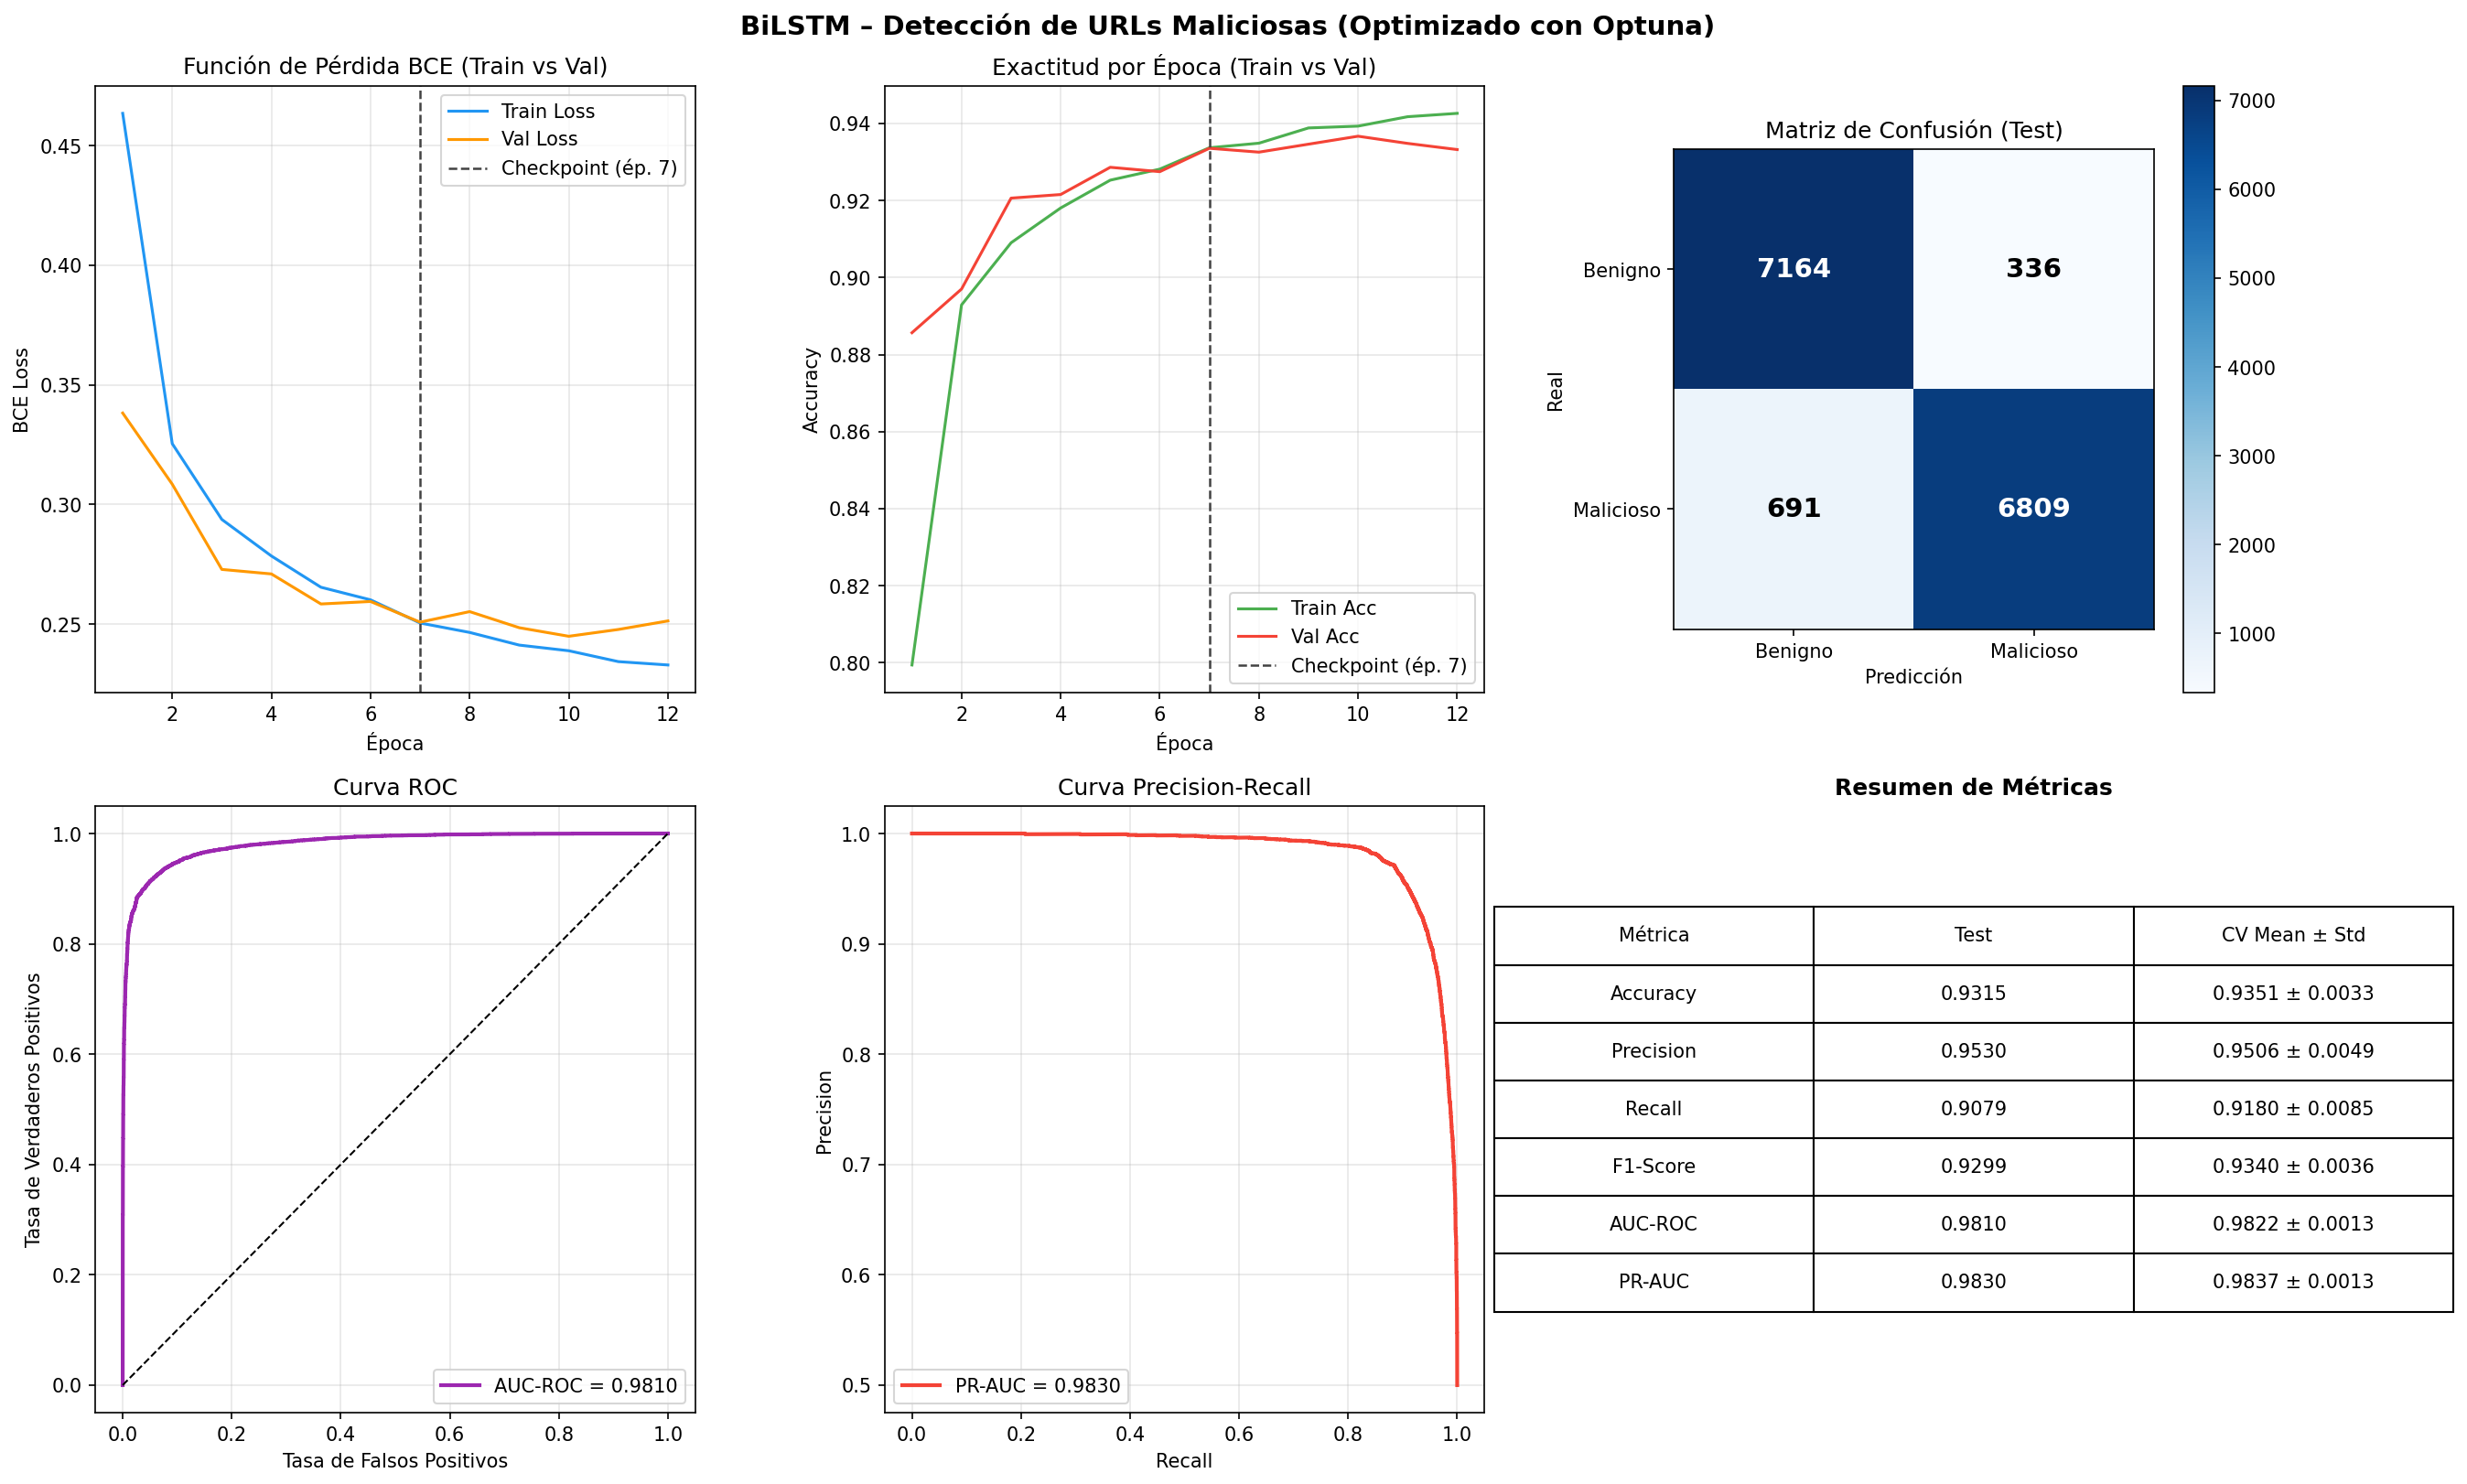


ETAPA 7a – Test Externo LATAM
  [LATAM] URLs con protocolo / www. eliminado: 920 de 3,000 (30.7 %)
  [LATAM] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test LATAM
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test LATAM] ⚠  158 URLs (5.3%) superan MAX_LEN=102 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test LATAM                                 │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.8110                      │
  │  Precisión (Precision)   │  0.8602                      │
  │  Exhaustividad (Recall)  │  0.7427                      │
  │  F1-Score                │  0.7971                      │
  │  AUC-ROC                 │  0.8648                      │
  │  PR-AUC                  │  0.8765                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
              P

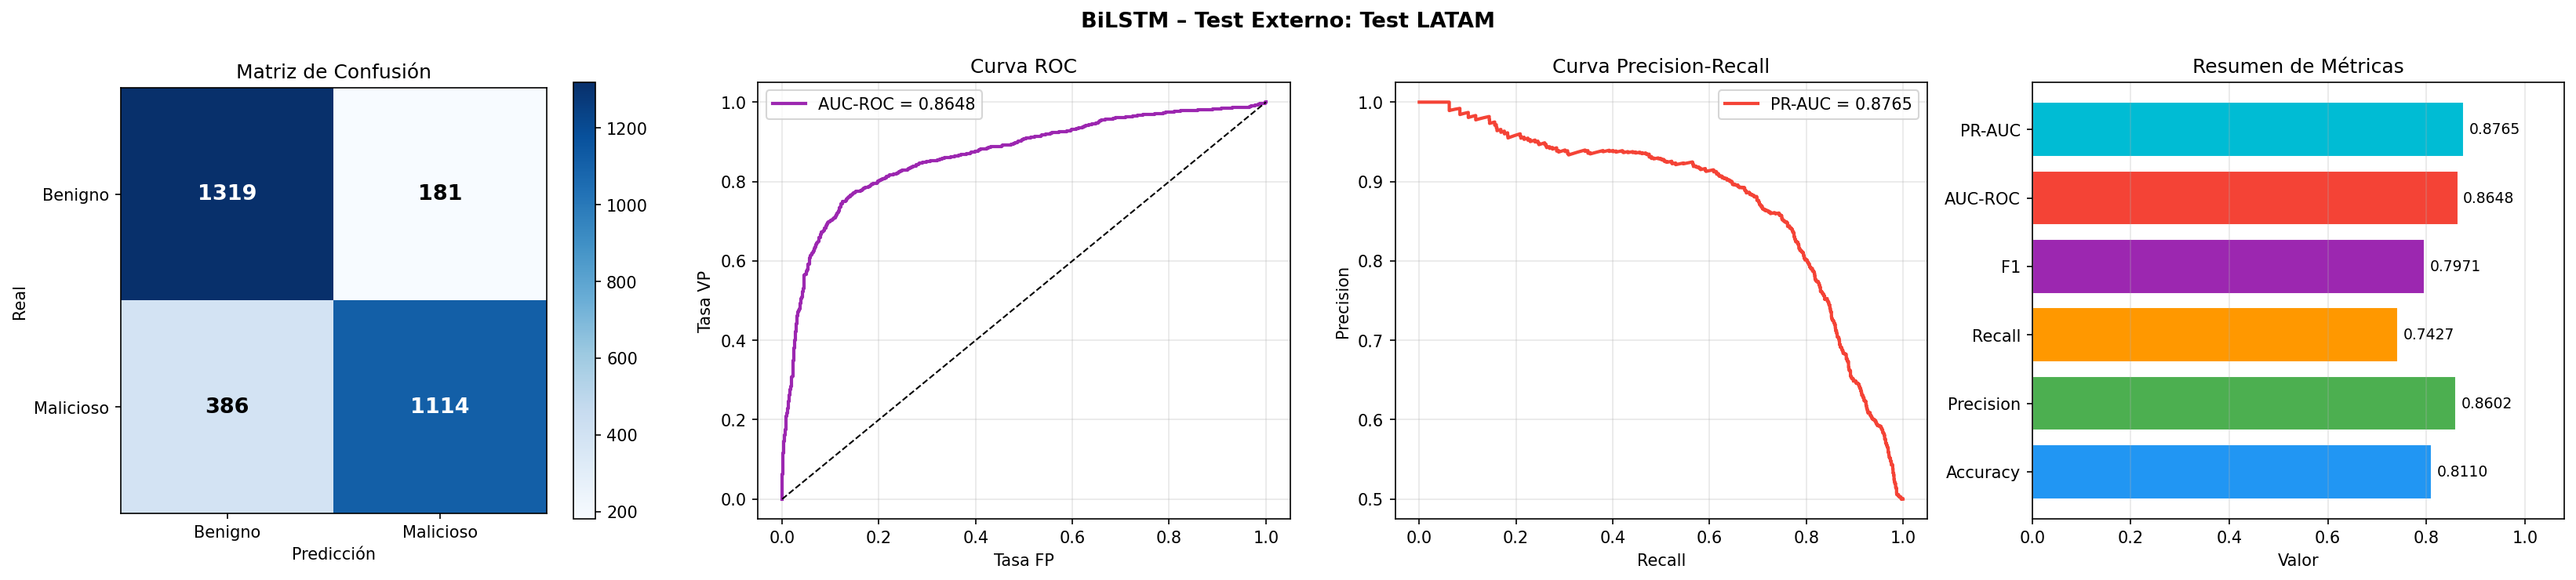


ETAPA 7b – Test Externo Genérico
  [Genérico] URLs con protocolo / www. eliminado: 0 de 3,000 (0.0 %)
  [Genérico] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test Genérico
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test Genérico] ⚠  217 URLs (7.2%) superan MAX_LEN=102 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test Genérico                              │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9400                      │
  │  Precisión (Precision)   │  0.9688                      │
  │  Exhaustividad (Recall)  │  0.9093                      │
  │  F1-Score                │  0.9381                      │
  │  AUC-ROC                 │  0.9910                      │
  │  PR-AUC                  │  0.9905                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
   

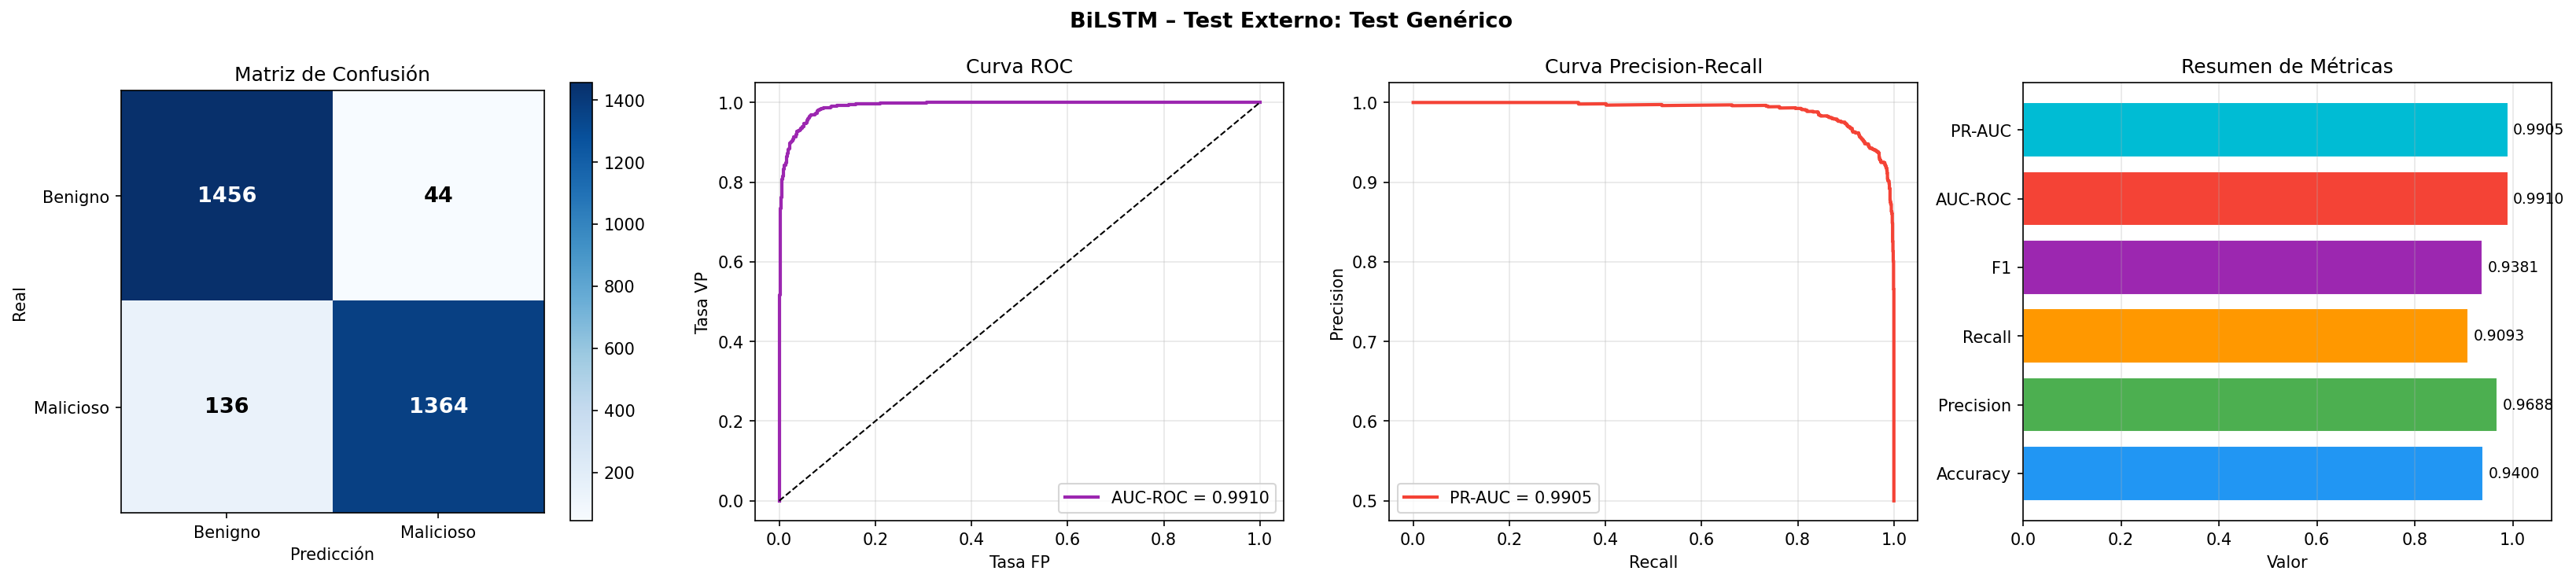


COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico

  Conjunto                       Acc    Prec     Rec      F1   AUC-ROC   PR-AUC
  -----------------------------------------------------------------------------
  Test Interno (15 %)         0.9315  0.9530  0.9079  0.9299    0.9810   0.9830
  Test LATAM (externo)        0.8110  0.8602  0.7427  0.7971    0.8648   0.8765
  Test Genérico (externo)     0.9400  0.9688  0.9093  0.9381    0.9910   0.9905

  ✓ Tabla comparativa guardada: outputs_bilstm/bilstm_comparacion_tests.csv
  ✓ Gráfica comparativa guardada: outputs_bilstm/bilstm_comparacion_tests.png


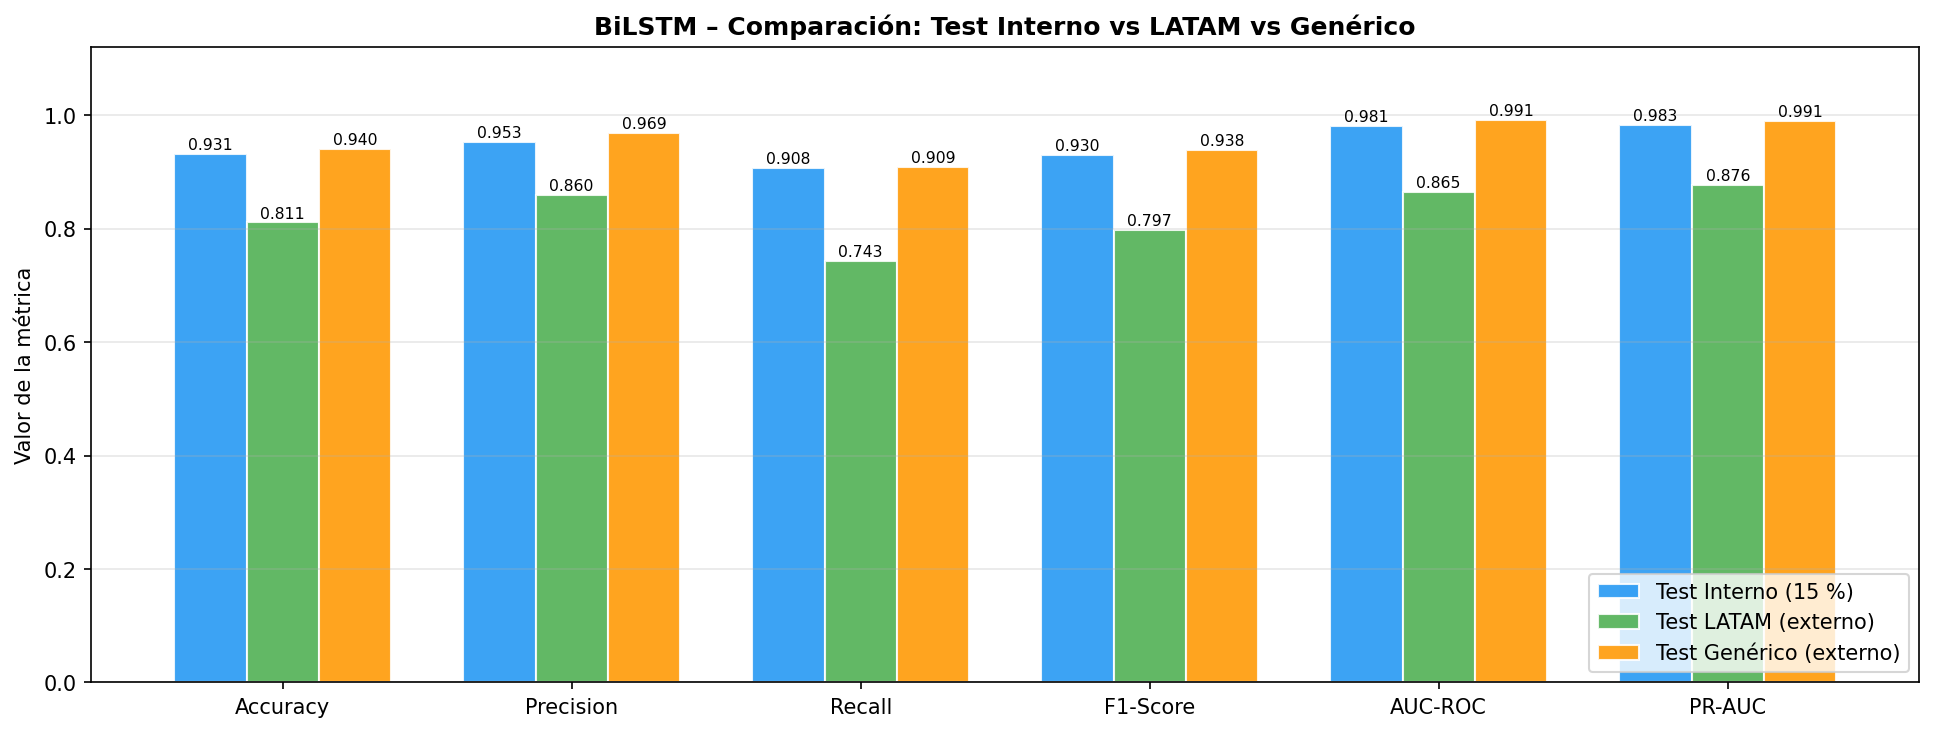


  ✅ Pipeline completo. Todos los resultados en: outputs_bilstm


In [6]:
# =============================================================================
# DETECCIÓN DE URLs MALICIOSAS – BiLSTM (Subashini & Narmatha, 2024)
# Arquitectura: Bidirectional LSTM  |  Optimización: Optuna  |  CV: k=5
# =============================================================================

import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import optuna
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")
from typing import Optional

optuna.logging.set_verbosity(optuna.logging.INFO)

# ---------------------------------------------------------------------------
# CONFIGURACIÓN GENERAL
# ---------------------------------------------------------------------------
SEED       = 42
OUTPUT_DIR = "outputs_bilstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ► Rutas de los tests externos (ajusta si cambian de ubicación)
EXT_BEN_LATAM = "prueba_latam/benigno_latam_1500.csv"
EXT_MAL_LATAM = "prueba_latam/phishing_latam_1500.csv"
EXT_BEN_GEN   = "prueba_generica/benigno_generico_1500.csv"
EXT_MAL_GEN   = "prueba_generica/phishing_generico_1500.csv"

torch.manual_seed(SEED)
np.random.seed(SEED)


# ---------------------------------------------------------------------------
# UTILIDAD: Limpieza de URL (quitar protocolo)
# ---------------------------------------------------------------------------
# Se aplica ANTES de cualquier tokenización, tanto al dataset principal
# como a los tests externos, para garantizar consistencia.
#
# Protocolo eliminado: http://, https://, ftp://, ftps://
# Prefijo eliminado  : www.  (solo si aparece al inicio, tras quitar protocolo)
# ---------------------------------------------------------------------------
_PROTO_RE = re.compile(r'^(?:https?|ftps?)://', re.IGNORECASE)
_WWW_RE   = re.compile(r'^www\.', re.IGNORECASE)

def clean_url(url: str) -> str:
    """
    Elimina el protocolo (http/https/ftp/ftps) y el prefijo 'www.'
    de una URL, dejando solo el host + path + query.

    Ejemplos:
      'https://www.example.com/path' → 'example.com/path'
      'http://phishing.site/login'   → 'phishing.site/login'
      'www.google.com'               → 'google.com'
      'google.com'                   → 'google.com'   (sin cambios)
    """
    url = str(url).strip()
    url = _PROTO_RE.sub('', url)   # quitar protocolo
    url = _WWW_RE.sub('', url)     # quitar www. inicial
    return url


# ---------------------------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Carga del Dataset")
print("=" * 70)

# ► Ajusta esta ruta a tu dataset real
DATA_PATH = "/content/dataset_merged2.csv"   # columnas esperadas: url, label, estrato

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["url", "label"]).reset_index(drop=True)
df["url"]   = df["url"].astype(str).str.strip()
df          = df[df["url"].str.len() > 0].reset_index(drop=True)
df["url"]   = df["url"].apply(clean_url)   # mismo pipeline que tests externos
df["label"] = df["label"].astype(int)

# Validar que los labels sean estrictamente binarios {0, 1}
labels_unicos = set(df["label"].unique())
assert labels_unicos <= {0, 1}, (
    f"[ETAPA 1] Labels inesperados en dataset_merged: {labels_unicos}. "
    "Solo se admiten 0 (benigno) y 1 (malicioso)."
)

print(f"  Total muestras : {len(df):,}")
print(f"  Benignas (0)   : {(df['label']==0).sum():,}")
print(f"  Maliciosas (1) : {(df['label']==1).sum():,}")
print(f"  Estratos únicos: {df['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 2. STRATIFIED SPLIT POR ESTRATO
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)")
print("         por estrato")
print("=" * 70)

# Train 70%, Temp 30%
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['estrato']
)
# Val 15%, Test 15%
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['estrato']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"\n  Estratos únicos – Train: {df_train['estrato'].nunique()} "
      f"| Val: {df_val['estrato'].nunique()} | Test: {df_test['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 3. PREPROCESAMIENTO – TOKENIZACIÓN, EMBEDDINGS Y PADDING
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 3 – Tokenización a nivel de carácter, Embeddings y Padding")
print("=" * 70)

# 3.1 Vocabulario de caracteres (construido SOLO con Train)
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

all_chars   = Counter("".join(df_train["url"].values))
vocab_chars = [PAD_TOKEN, UNK_TOKEN] + [ch for ch, _ in all_chars.most_common()]
char2idx    = {ch: idx for idx, ch in enumerate(vocab_chars)}
idx2char    = {idx: ch for ch, idx in char2idx.items()}

VOCAB_SIZE = len(vocab_chars)
PAD_IDX    = char2idx[PAD_TOKEN]
UNK_IDX    = char2idx[UNK_TOKEN]

print(f"  Tamaño de vocabulario de caracteres: {VOCAB_SIZE}")

# 3.2 Longitud máxima (percentil 95 del dataset de entrenamiento)
lengths = df_train["url"].str.len().values
MAX_LEN = int(np.percentile(lengths, 95))
print(f"  Longitud máxima (percentil 95): {MAX_LEN} caracteres")

# 3.3 Función de tokenización
def tokenize(url: str, char2idx: dict, max_len: int,
             pad_idx: int, unk_idx: int) -> list:
    """Convierte una URL en secuencia de índices con padding/truncado."""
    tokens = [char2idx.get(ch, unk_idx) for ch in str(url)[:max_len]]
    tokens += [pad_idx] * (max_len - len(tokens))
    return tokens

# 3.4 Tokenizar splits
print("  Tokenizando splits...")

def tokenize_split(df_split: pd.DataFrame) -> np.ndarray:
    """
    Tokeniza el campo 'url' del DataFrame dado.
    IMPORTANTE: las URLs ya deben llegar limpias (sin protocolo) antes
    de llamar a esta función.
    """
    return np.array([
        tokenize(url, char2idx, MAX_LEN, PAD_IDX, UNK_IDX)
        for url in df_split["url"].values
    ], dtype=np.int32)

X_train = tokenize_split(df_train)
X_val   = tokenize_split(df_val)
X_test  = tokenize_split(df_test)

y_train = df_train["label"].values.astype(np.float32)
y_val   = df_val["label"].values.astype(np.float32)
y_test  = df_test["label"].values.astype(np.float32)

print(f"  X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"  X_val   shape: {X_val.shape}   | y_val   shape: {y_val.shape}")
print(f"  X_test  shape: {X_test.shape}  | y_test  shape: {y_test.shape}")

# 3.5 Guardar CSV de tokens (muestra de 5000 filas para visualización)
SAMPLE_N = min(5000, len(X_train))

token_cols = [f"t{i}" for i in range(MAX_LEN)]
df_tokens  = pd.DataFrame(X_train[:SAMPLE_N], columns=token_cols)
df_tokens.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_tokens.insert(1, "label", df_train["label"].values[:SAMPLE_N])
tokens_path = os.path.join(OUTPUT_DIR, "preprocessing_tokens.csv")
df_tokens.to_csv(tokens_path, index=False)
print(f"\n  ✓ Guardado tokens (muestra): {tokens_path}")

EMB_DIM = 64
np.random.seed(SEED)
emb_matrix     = np.random.randn(VOCAB_SIZE, EMB_DIM).astype(np.float32) * 0.01
url_embeddings = np.array([
    emb_matrix[X_train[i]].mean(axis=0)
    for i in range(SAMPLE_N)
], dtype=np.float32)
emb_cols      = [f"emb_{i}" for i in range(EMB_DIM)]
df_embeddings = pd.DataFrame(url_embeddings, columns=emb_cols)
df_embeddings.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_embeddings.insert(1, "label", df_train["label"].values[:SAMPLE_N])
emb_path = os.path.join(OUTPUT_DIR, "preprocessing_embeddings.csv")
df_embeddings.to_csv(emb_path, index=False)
print(f"  ✓ Guardado embeddings (muestra): {emb_path}")

df_padding = pd.DataFrame({
    "url":              df_train["url"].values[:SAMPLE_N],
    "label":            df_train["label"].values[:SAMPLE_N],
    "url_length":       df_train["url"].str.len().values[:SAMPLE_N],
    "padded_length":    MAX_LEN,
    "truncated":        df_train["url"].str.len().values[:SAMPLE_N] > MAX_LEN,
    "pad_tokens_added": np.maximum(
        0, MAX_LEN - df_train["url"].str.len().values[:SAMPLE_N]
    )
})
padding_path = os.path.join(OUTPUT_DIR, "preprocessing_padding.csv")
df_padding.to_csv(padding_path, index=False)
print(f"  ✓ Guardado padding (muestra): {padding_path}")

print(f"\n  Vocab size        : {VOCAB_SIZE}")
print(f"  Emb dim (default) : {EMB_DIM}")
print(f"  Max length        : {MAX_LEN}")


# ---------------------------------------------------------------------------
# 4. DATASET PyTorch Y DEFINICIÓN DEL MODELO BiLSTM
#    Arquitectura: Subashini & Narmatha (2024) – solo la parte BiLSTM
#    (sin CNN/FRCNN ni Naïve Bayes; embeddings de caracteres + BiLSTM + MLP)
# ---------------------------------------------------------------------------
class URLDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = URLDataset(X_train, y_train)
val_ds   = URLDataset(X_val,   y_val)
test_ds  = URLDataset(X_test,  y_test)


# ─────────────────────────────────────────────────────────────────────────────
# BiLSTM  (Bidirectional Long Short-Term Memory)
#   • Embedding de caracteres  →  BiLSTM  →  concatenación h_forward + h_backward
#   →  Dropout  →  capa densa (clasificador binario)
#
# Cambios respecto al LSTM unidireccional:
#   1. bidirectional=True  en nn.LSTM
#   2. Último estado oculto: concatenación de hn[-2] (forward) y hn[-1] (backward)
#   3. Clasificador recibe hidden_dim * 2 en lugar de hidden_dim
# ─────────────────────────────────────────────────────────────────────────────
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int,
                 num_layers: int, dropout: float, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx
        )
        self.bilstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True          # ← BiLSTM: procesa la URL en ambas direcciones
        )
        self.dropout    = nn.Dropout(dropout)
        # hidden_dim * 2 porque concatenamos el estado forward y el backward
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))                 # (B, L, emb_dim)
        _, (hn, _) = self.bilstm(emb)
        # hn shape: (num_layers * 2, B, hidden_dim)
        # hn[-2] → último estado del forward pass
        # hn[-1] → último estado del backward pass
        last_hidden = torch.cat([hn[-2], hn[-1]], dim=1)      # (B, hidden_dim*2)
        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden).squeeze(1)      # (B,)
        return logits


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Dispositivo de cómputo: {DEVICE}")

import torch.nn.functional as F

class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight
        )


# ---------------------------------------------------------------------------
# Helper: run_epoch
# ---------------------------------------------------------------------------
def run_epoch(loader, model, criterion, optimizer, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == y_batch.long()).sum().item()
            total      += len(y_batch)

    if total == 0:
        return 0.0, 0.0
    return total_loss / total, correct / total


def generalization_score(tr_loss: float, vl_loss: float,
                         tr_acc: float, vl_acc: float,
                         w_loss: float = 1.0, w_acc: float = 0.5) -> float:
    """
    Métrica compuesta (menor = mejor) para elegir el checkpoint con menos
    sobreajuste. Penaliza cuando train supera claramente a val en loss o acc.
    """
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)
    return vl_loss + w_loss * loss_gap + w_acc * acc_gap


# ---------------------------------------------------------------------------
# 5. BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 4 – Búsqueda de Hiperparámetros con Optuna")
print("=" * 70)

def objective(trial):
    hidden_dim   = trial.suggest_categorical("hidden_dim",   [64, 128, 256])
    num_layers   = trial.suggest_int("num_layers", 1, 3)
    dropout      = trial.suggest_float("dropout",  0.3, 0.6)
    lr           = trial.suggest_float("lr",       1e-4, 1e-2, log=True)
    emb_dim      = trial.suggest_categorical("emb_dim",      [32, 64, 128])
    batch_size   = trial.suggest_categorical("batch_size",   [32, 64, 128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)

    train_loader_opt = DataLoader(train_ds, batch_size=batch_size,
                                  shuffle=True,  num_workers=0, pin_memory=True)
    val_loader_opt   = DataLoader(val_ds,   batch_size=batch_size,
                                  shuffle=False, num_workers=0, pin_memory=True)

    model_opt = BiLSTMModel(
        vocab_size=VOCAB_SIZE, emb_dim=emb_dim,
        hidden_dim=hidden_dim, num_layers=num_layers,
        dropout=dropout, pad_idx=PAD_IDX
    ).to(DEVICE)

    criterion_opt = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_opt = torch.optim.Adam(model_opt.parameters(),
                                     lr=lr, weight_decay=weight_decay)

    for epoch in range(10):
        model_opt.train()
        for X_batch, y_batch in train_loader_opt:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer_opt.zero_grad()
            loss = criterion_opt(model_opt(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model_opt.parameters(), max_norm=5.0)
            optimizer_opt.step()

        model_opt.eval()
        val_loss, n_samples = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_opt:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                loss      = criterion_opt(model_opt(X_batch), y_batch)
                val_loss += loss.item() * len(y_batch)
                n_samples += len(y_batch)

        val_loss /= n_samples
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
print("Iniciando optimización con Optuna (50 trials)...")
study.optimize(objective, n_trials=50)

print("\n🏆 Mejores hiperparámetros encontrados:")
best_params = study.best_params
for k, v in best_params.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------------
# 6. ENTRENAMIENTO FINAL CON MEJORES PARÁMETROS
#    (70 % Train | 15 % Val para monitoreo | 15 % Test)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)")
print("=" * 70)

MAX_EPOCHS_FINAL = 50
PATIENCE_ES      = 5          # parar antes si la generalización no mejora
MIN_DELTA_GEN    = 1e-4       # mejora mínima en score de generalización
GAP_LOSS_WEIGHT  = 1.0       # peso brecha val_loss - train_loss
GAP_ACC_WEIGHT   = 0.5        # peso brecha train_acc - val_acc

X_final = tokenize_split(df_train)
y_final = df_train["label"].values.astype(np.float32)

final_ds = URLDataset(X_final, y_final)

BEST_BATCH         = best_params["batch_size"]
final_loader       = DataLoader(final_ds, batch_size=BEST_BATCH,
                                shuffle=True,  num_workers=2, pin_memory=True)
val_monitor_loader = DataLoader(val_ds,   batch_size=BEST_BATCH,
                                shuffle=False, num_workers=2, pin_memory=True)
test_loader        = DataLoader(test_ds,  batch_size=BEST_BATCH,
                                shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"  Épocas máx: {MAX_EPOCHS_FINAL}")
print(f"  Checkpoint: score generalización (val_loss + gap train-val)")
print(f"  EarlyStopping: patience={PATIENCE_ES}, min_delta={MIN_DELTA_GEN}")

# Modelo BiLSTM con best_params
best_model = BiLSTMModel(
    vocab_size=VOCAB_SIZE,
    emb_dim=best_params["emb_dim"],
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    pad_idx=PAD_IDX
).to(DEVICE)

# Ponderación positiva para mitigar desbalance (sin tocar el split)
pos = float((y_final == 1).sum())
neg = float((y_final == 0).sum())
pos_weight = None
if pos > 0 and neg > 0:
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
    print(f"  pos_weight (neg/pos): {pos_weight.item():.4f}")

criterion = SmoothBCEWithLogitsLoss(smoothing=0.05, pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

# Reduce LR cuando la validación se estanca (ayuda a generalizar)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5, min_lr=1e-6
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "gen_score":  [], "loss_gap": [], "acc_gap":  [],
}

t0 = time.time()
best_gen_score   = float("inf")
best_val_loss    = float("inf")
best_state       = None
best_epoch       = 0
best_val_epoch   = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    tr_loss, tr_acc = run_epoch(final_loader,       best_model, criterion,
                                optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_monitor_loader, best_model, criterion,
                                optimizer, train=False)

    gen_score = generalization_score(
        tr_loss, vl_loss, tr_acc, vl_acc,
        w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
    )
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["gen_score"].append(gen_score)
    history["loss_gap"].append(loss_gap)
    history["acc_gap"].append(acc_gap)

    scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_val_epoch = epoch

    # Checkpoint: menor sobreajuste (no solo menor val_loss)
    if gen_score < best_gen_score - MIN_DELTA_GEN:
        best_gen_score = gen_score
        best_epoch     = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in best_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        marker = " *" if epoch == best_epoch else ""
        print(f"  Época {epoch:3d}/{MAX_EPOCHS_FINAL}{marker} | "
              f"Loss → Train: {tr_loss:.4f}  Val: {vl_loss:.4f} | "
              f"Acc  → Train: {tr_acc:.4f}  Val: {vl_acc:.4f} | "
              f"Gen: {gen_score:.4f} (gap L/A: {loss_gap:.4f}/{acc_gap:.4f}) | "
              f"LR: {current_lr:.2e} | Tiempo: {elapsed:.1f}s")

    if patience_counter >= PATIENCE_ES:
        print(f"  ⏹ EarlyStopping en época {epoch} "
              f"(mejor generalización: época {best_epoch}, gen={best_gen_score:.4f}).")
        break

# Restaurar checkpoint con mejor equilibrio train/val
if best_state is not None:
    best_model.load_state_dict(best_state)

model_path = os.path.join(OUTPUT_DIR, "bilstm_best_optuna_model.pt")
torch.save({k: v.cpu().clone() for k, v in best_model.state_dict().items()}, model_path)

idx = best_epoch - 1
print(f"\n  ✓ Entrenamiento completado")
print(f"  ✓ Época guardada (menor sobreajuste): {best_epoch}")
print(f"      Train loss/acc: {history['train_loss'][idx]:.4f} / {history['train_acc'][idx]:.4f}")
print(f"      Val   loss/acc: {history['val_loss'][idx]:.4f} / {history['val_acc'][idx]:.4f}")
print(f"      Gen score: {best_gen_score:.4f} | gap loss: {history['loss_gap'][idx]:.4f} | "
      f"gap acc: {history['acc_gap'][idx]:.4f}")
if best_val_epoch != best_epoch:
    j = best_val_epoch - 1
    print(f"  ℹ Época con menor val_loss pura: {best_val_epoch} "
          f"(val_loss={history['val_loss'][j]:.4f}, "
          f"train_acc-val_acc={history['acc_gap'][j]:.4f}) — no seleccionada por overfitting")
print(f"  ✓ Modelo guardado en: {model_path}")


# ---------------------------------------------------------------------------
# 7. CROSS-VALIDATION (k=5) CON best_params
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5.5 – Cross-Validation (k=5) con best_params")
print("=" * 70)

df_cv = pd.concat([df_train, df_val], ignore_index=True)
X_cv  = tokenize_split(df_cv)
y_cv  = df_cv["label"].values.astype(np.float32)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_cv, df_cv['estrato']), 1):

    X_tr_fold  = X_cv[train_idx];   y_tr_fold  = y_cv[train_idx]
    X_val_fold = X_cv[val_idx];     y_val_fold = y_cv[val_idx]

    tr_ds_fold  = URLDataset(X_tr_fold,  y_tr_fold)
    val_ds_fold = URLDataset(X_val_fold, y_val_fold)

    tr_loader_fold  = DataLoader(tr_ds_fold,  batch_size=BEST_BATCH,
                                 shuffle=True,  num_workers=2, pin_memory=True)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=BEST_BATCH,
                                 shuffle=False, num_workers=2, pin_memory=True)

    model_cv = BiLSTMModel(
        vocab_size=VOCAB_SIZE,
        emb_dim=best_params["emb_dim"],
        hidden_dim=best_params["hidden_dim"],
        num_layers=best_params["num_layers"],
        dropout=best_params["dropout"],
        pad_idx=PAD_IDX
    ).to(DEVICE)

    criterion_cv = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_cv = torch.optim.Adam(
        model_cv.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )
    scheduler_cv = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode="min", patience=3, factor=0.3, min_lr=1e-6
    )

    best_cv_gen         = float("inf")
    best_cv_state       = None
    cv_patience_counter = 0
    stop_epoch          = MAX_EPOCHS_FINAL

    for epoch in range(1, MAX_EPOCHS_FINAL + 1):
        # Warmup lineal de 3 épocas para cross-validation
        if epoch <= 3:
            warmup_factor = epoch / 3.0
            current_lr = best_params["lr"] * warmup_factor
            for param_group in optimizer_cv.param_groups:
                param_group['lr'] = current_lr

        tr_loss_cv, tr_acc_cv = run_epoch(tr_loader_fold,  model_cv, criterion_cv,
                                          optimizer_cv, train=True)
        vl_loss_cv, vl_acc_cv = run_epoch(val_loader_fold, model_cv, criterion_cv,
                                          optimizer_cv, train=False)

        # Solo activar el scheduler después del warmup
        if epoch > 3:
            scheduler_cv.step(vl_loss_cv)

        gen_cv = generalization_score(
            tr_loss_cv, vl_loss_cv, tr_acc_cv, vl_acc_cv,
            w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
        )

        if gen_cv < best_cv_gen - MIN_DELTA_GEN:
            best_cv_gen           = gen_cv
            best_cv_state         = {k: v.cpu().clone()
                                     for k, v in model_cv.state_dict().items()}
            cv_patience_counter   = 0
        else:
            cv_patience_counter += 1

        if cv_patience_counter >= PATIENCE_ES:
            stop_epoch = epoch
            break

    if best_cv_state is not None:
        model_cv.load_state_dict(best_cv_state)
    model_cv.eval()

    fold_logits, fold_preds, fold_labels = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_fold:
            X_b    = X_b.to(DEVICE)
            logits = model_cv(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            fold_logits.extend(probs.tolist())
            fold_preds.extend(preds.tolist())
            fold_labels.extend(y_b.numpy().tolist())

    y_t       = np.array(fold_labels, dtype=int)
    y_p       = np.array(fold_preds,  dtype=int)
    y_prob_cv = np.array(fold_logits)

    f_acc  = accuracy_score(y_t, y_p)
    f_prec = precision_score(y_t, y_p, zero_division=0)
    f_rec  = recall_score(y_t, y_p,    zero_division=0)
    f_f1   = f1_score(y_t, y_p,        zero_division=0)
    f_roc  = roc_auc_score(y_t, y_prob_cv)
    f_pr   = average_precision_score(y_t, y_prob_cv)

    cv_results.append({
        "fold": fold, "Accuracy": f_acc, "Precision": f_prec,
        "Recall": f_rec, "F1": f_f1, "AUC_ROC": f_roc, "PR_AUC": f_pr
    })

    print(f"  Fold {fold}/5 | F1: {f_f1:.4f} | AUC-ROC: {f_roc:.4f} "
          f"| Época stop: {stop_epoch}")

cv_df       = pd.DataFrame(cv_results)
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
cv_mean     = cv_df[metric_keys].mean()
cv_std      = cv_df[metric_keys].std()

label_map = {
    "Accuracy":  "Accuracy",
    "Precision": "Precision",
    "Recall":    "Recall",
    "F1":        "F1-Score",
    "AUC_ROC":   "AUC-ROC",
    "PR_AUC":    "PR-AUC",
}

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤""")
for key in metric_keys:
    print(f"  │ {label_map[key]:<24s} │   {cv_mean[key]:.4f}     │  ±{cv_std[key]:.4f}       │")
print("  └──────────────────────────┴──────────────┴───────────────┘")

cv_export = cv_df.copy()
mean_row  = {col: (cv_mean[col] if col in metric_keys else "mean") for col in cv_export.columns}
std_row   = {col: (cv_std[col]  if col in metric_keys else "std")  for col in cv_export.columns}
cv_export = pd.concat(
    [cv_export, pd.DataFrame([mean_row]), pd.DataFrame([std_row])],
    ignore_index=True
)
cv_path = os.path.join(OUTPUT_DIR, "bilstm_cv_results.csv")
cv_export.to_csv(cv_path, index=False)
print(f"\n  ✓ Guardado CV results: {cv_path}")


# ---------------------------------------------------------------------------
# 8. EVALUACIÓN EN TEST SET
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 6 – Evaluación en Test Set")
print("=" * 70)

best_model.eval()
all_logits, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = best_model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        all_logits.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.numpy().tolist())

y_true  = np.array(all_labels, dtype=int)
y_pred  = np.array(all_preds,  dtype=int)
y_prob  = np.array(all_logits)

acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred,  zero_division=0)
rec     = recall_score(y_true, y_pred,     zero_division=0)
f1      = f1_score(y_true, y_pred,         zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
cm      = confusion_matrix(y_true, y_pred)

print(f"""
  ┌─────────────────────────────────────────────┐
  │        MÉTRICAS DE EVALUACIÓN – BiLSTM      │
  ├──────────────────────────┬──────────────────┤
  │  Exactitud (Accuracy)    │  {acc:.4f}          │
  │  Precisión (Precision)   │  {prec:.4f}          │
  │  Exhaustividad (Recall)  │  {rec:.4f}          │
  │  F1-Score                │  {f1:.4f}          │
  │  AUC-ROC                 │  {roc_auc:.4f}          │
  │  PR-AUC                  │  {pr_auc:.4f}          │
  └──────────────────────────┴──────────────────┘
""")

print("  Matriz de Confusión:")
print(f"              Pred 0  Pred 1")
print(f"  Real 0  :   {cm[0,0]:6d}  {cm[0,1]:6d}   (TN / FP)")
print(f"  Real 1  :   {cm[1,0]:6d}  {cm[1,1]:6d}   (FN / TP)")
print("\n  Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["Benigno", "Malicioso"]))


# ---------------------------------------------------------------------------
# 9. GUARDAR MÉTRICAS Y GRÁFICAS
# ---------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Modelo":    ["BiLSTM"],
    "Best_Epoch": [best_epoch],
    "Accuracy":  [round(acc,     4)],
    "Precision": [round(prec,    4)],
    "Recall":    [round(rec,     4)],
    "F1_Score":  [round(f1,      4)],
    "AUC_ROC":   [round(roc_auc, 4)],
    "PR_AUC":    [round(pr_auc,  4)],
    "TN": [cm[0,0]], "FP": [cm[0,1]],
    "FN": [cm[1,0]], "TP": [cm[1,1]],
})
metrics_path = os.path.join(OUTPUT_DIR, "bilstm_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

history_df = pd.DataFrame(history)
history_df.index.name = "epoch"
history_path = os.path.join(OUTPUT_DIR, "bilstm_training_history.csv")
history_df.to_csv(history_path)

epochs_ran = len(history["train_loss"])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "BiLSTM – Detección de URLs Maliciosas (Optimizado con Optuna)",
    fontsize=14, fontweight="bold"
)

# Pérdida BCE (Train vs Val)
ax = axes[0, 0]
ax.plot(ep_range, history["train_loss"], label="Train Loss", color="#2196F3")
ax.plot(ep_range, history["val_loss"],   label="Val Loss",   color="#FF9800")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Función de Pérdida BCE (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy (Train vs Val)
ax = axes[0, 1]
ax.plot(ep_range, history["train_acc"], label="Train Acc", color="#4CAF50")
ax.plot(ep_range, history["val_acc"],   label="Val Acc",   color="#F44336")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Exactitud por Época (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)

# Matriz de confusión
ax = axes[0, 2]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight="bold")
ax.set_title("Matriz de Confusión (Test)")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

# Curva ROC
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color="#9C27B0", lw=2, label=f"AUC-ROC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(); ax.grid(True, alpha=0.3)

# Curva Precision-Recall
ax = axes[1, 1]
prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
ax.plot(rec_c, prec_c, color="#F44336", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True, alpha=0.3)

# Tabla resumen métricas (Test + CV mean±std)
ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Métrica",    "Test",           "CV Mean ± Std"],
    ["Accuracy",   f"{acc:.4f}",     f"{cv_mean['Accuracy']:.4f} ± {cv_std['Accuracy']:.4f}"],
    ["Precision",  f"{prec:.4f}",    f"{cv_mean['Precision']:.4f} ± {cv_std['Precision']:.4f}"],
    ["Recall",     f"{rec:.4f}",     f"{cv_mean['Recall']:.4f} ± {cv_std['Recall']:.4f}"],
    ["F1-Score",   f"{f1:.4f}",      f"{cv_mean['F1']:.4f} ± {cv_std['F1']:.4f}"],
    ["AUC-ROC",    f"{roc_auc:.4f}", f"{cv_mean['AUC_ROC']:.4f} ± {cv_std['AUC_ROC']:.4f}"],
    ["PR-AUC",     f"{pr_auc:.4f}",  f"{cv_mean['PR_AUC']:.4f} ± {cv_std['PR_AUC']:.4f}"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.6, 2.2)
ax.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "bilstm_results_optuna.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"\n  Pipeline completado (test interno). Resultados guardados en: {OUTPUT_DIR}")
display(Image(plot_path))


# ---------------------------------------------------------------------------
# 10. TESTS EXTERNOS
#     · Test LATAM    : benignos_test_latam_3000    + phishing_test_latam_3000
#     · Test Genérico : benignos_test_generico_3000 + phishing_test_generico_3000
#
#  PREPROCESAMIENTO PREVIO A LA TOKENIZACIÓN:
#   1. Se normaliza el nombre de la columna URL (acepta 'url' o 'URL').
#   2. Se asigna label=0 a los benignos y label=1 a los maliciosos
#      (la asignación es explícita e independiente del contenido del CSV).
#   3. Se aplica clean_url() → elimina protocolo y www. de cada URL
#      usando el MISMO regex que se usó para el dataset de entrenamiento.
#   4. Solo entonces se tokeniza con el vocabulario construido sobre Train.
# ---------------------------------------------------------------------------

def load_external_set(path_ben: str, path_mal: str, nombre: str) -> pd.DataFrame:
    """
    Carga los CSV benignos (label=0) y maliciosos (label=1),
    normaliza el nombre de columna, asigna labels correctos,
    y aplica clean_url() antes de devolver el DataFrame.

    Pasos internos
    --------------
    1. Leer CSV y normalizar nombres de columna a minúsculas + strip.
    2. Verificar que exista la columna 'url'; lanzar error descriptivo si no.
    3. Asignar label=0 a todos los benignos y label=1 a todos los maliciosos
       (no se confía en ninguna columna 'label' preexistente en los CSVs externos).
    4. Eliminar filas con URL nula o vacía.
    5. Aplicar clean_url(): quitar protocolo y www. para que el vocabulario
       de Train reconozca los tokens correctamente.
    6. Imprimir resumen de limpieza de protocolos.
    """
    df_b = pd.read_csv(path_ben)
    df_m = pd.read_csv(path_mal)

    # ── Paso 1: normalizar nombres de columna ───────────────────────────────
    for d in [df_b, df_m]:
        d.columns = [c.strip().lower() for c in d.columns]

    # ── Paso 2: verificar que exista columna 'url' ──────────────────────────
    for d, path in [(df_b, path_ben), (df_m, path_mal)]:
        if "url" not in d.columns:
            raise ValueError(
                f"[{nombre}] No se encontró columna 'url' en '{path}'.\n"
                f"  Columnas disponibles: {d.columns.tolist()}"
            )

    # ── Paso 3: seleccionar solo 'url' y asignar label explícitamente ───────
    #    (ignoramos cualquier columna 'label' que pueda traer el CSV externo)
    df_b = df_b[["url"]].copy()
    df_m = df_m[["url"]].copy()
    df_b["label"] = 0   # benigno
    df_m["label"] = 1   # malicioso / phishing

    # ── Paso 4: eliminar filas nulas/vacías ─────────────────────────────────
    df_ext = pd.concat([df_b, df_m], ignore_index=True)
    df_ext["url"] = df_ext["url"].astype(str).str.strip()
    antes = len(df_ext)
    df_ext = df_ext[df_ext["url"].str.len() > 0].reset_index(drop=True)
    if antes - len(df_ext) > 0:
        print(f"  [{nombre}] ⚠  Se eliminaron {antes - len(df_ext)} filas con URL vacía.")

    # ── Paso 5: limpiar protocolos ANTES de tokenizar (igual que train) ────
    urls_originales = df_ext["url"].copy()
    df_ext["url"]   = df_ext["url"].apply(clean_url)

    # ── Paso 5b: auditoría rápida (unicidad, espacios) ───────────────────────
    n_cambiadas = (urls_originales != df_ext["url"]).sum()
    n_ws = urls_originales.str.contains(r"\s", regex=True).sum()
    if n_ws:
        print(f"  [{nombre}] ⚠  URLs con espacios antes de strip: {n_ws}")

    n_dup = df_ext["url"].duplicated().sum()
    if n_dup:
        print(f"  [{nombre}] ⚠  URLs duplicadas tras clean_url: {n_dup} "
              f"(se conserva la primera ocurrencia)")
        df_ext = df_ext.drop_duplicates(subset=["url"], keep="first").reset_index(drop=True)

    # ── Paso 6: informe de limpieza ─────────────────────────────────────────
    print(f"  [{nombre}] URLs con protocolo / www. eliminado: "
          f"{n_cambiadas:,} de {len(df_ext):,} "
          f"({n_cambiadas/len(df_ext)*100:.1f} %)")
    print(f"  [{nombre}] URLs únicas finales: {df_ext['url'].nunique():,} / {len(df_ext):,}")

    # ── Validación final de labels ───────────────────────────────────────────
    assert set(df_ext["label"].unique()) <= {0, 1}, (
        f"[{nombre}] Error interno: labels inesperados tras asignación."
    )
    assert (df_ext["label"] == 0).sum() > 0, (
        f"[{nombre}] Error: no hay muestras benignas (label=0)."
    )
    assert (df_ext["label"] == 1).sum() > 0, (
        f"[{nombre}] Error: no hay muestras maliciosas (label=1)."
    )

    return df_ext


def evaluar_externo(df_ext: pd.DataFrame, nombre: str, tag: str) -> dict:
    """
    Tokeniza con el vocab de Train, crea DataLoader y evalúa best_model.
    Devuelve dict con métricas y guarda CSV + gráfica.

    NOTA: df_ext ya llega con protocolo quitado (lo hace load_external_set).
    """
    print(f"\n{'='*70}")
    print(f"  Test Externo – {nombre}")
    print(f"  Muestras: {len(df_ext):,}  |  "
          f"Benignas (0): {(df_ext['label']==0).sum():,}  |  "
          f"Maliciosas (1): {(df_ext['label']==1).sum():,}")
    print(f"{'='*70}")

    # tokenize_split: mismo vocab/MAX_LEN/PAD/UNK que train (definidos en ETAPA 3)
    n_trunc = (df_ext["url"].str.len() > MAX_LEN).sum()
    if n_trunc:
        pct = n_trunc / len(df_ext) * 100
        print(f"  [{nombre}] ⚠  {n_trunc:,} URLs ({pct:.1f}%) superan MAX_LEN={MAX_LEN} "
              f"(se truncan como en train, percentil 95)")

    X_ext = tokenize_split(df_ext)
    y_ext = df_ext["label"].values.astype(np.float32)

    ext_ds     = URLDataset(X_ext, y_ext)
    ext_loader = DataLoader(ext_ds, batch_size=BEST_BATCH,
                            shuffle=False, num_workers=2, pin_memory=True)

    best_model.eval()
    ext_logits, ext_preds, ext_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in ext_loader:
            X_batch = X_batch.to(DEVICE)
            logits  = best_model(X_batch)
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs >= 0.5).astype(int)
            ext_logits.extend(probs.tolist())
            ext_preds.extend(preds.tolist())
            ext_labels.extend(y_batch.numpy().tolist())

    yt    = np.array(ext_labels, dtype=int)
    yp    = np.array(ext_preds,  dtype=int)
    yprob = np.array(ext_logits)

    e_acc  = accuracy_score(yt, yp)
    e_prec = precision_score(yt, yp, zero_division=0)
    e_rec  = recall_score(yt, yp,    zero_division=0)
    e_f1   = f1_score(yt, yp,        zero_division=0)
    e_roc  = roc_auc_score(yt, yprob)
    e_pr   = average_precision_score(yt, yprob)
    e_cm   = confusion_matrix(yt, yp)

    print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – {nombre:<43s}│
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  {e_acc:.4f}                      │
  │  Precisión (Precision)   │  {e_prec:.4f}                      │
  │  Exhaustividad (Recall)  │  {e_rec:.4f}                      │
  │  F1-Score                │  {e_f1:.4f}                      │
  │  AUC-ROC                 │  {e_roc:.4f}                      │
  │  PR-AUC                  │  {e_pr:.4f}                      │
  └──────────────────────────┴───────────────────────────────┘
""")

    print("  Matriz de Confusión:")
    print(f"              Pred 0  Pred 1")
    print(f"  Real 0  :   {e_cm[0,0]:6d}  {e_cm[0,1]:6d}   (TN / FP)")
    print(f"  Real 1  :   {e_cm[1,0]:6d}  {e_cm[1,1]:6d}   (FN / TP)")
    print("\n  Reporte de Clasificación:")
    print(classification_report(yt, yp, target_names=["Benigno", "Malicioso"]))

    # ── CSV métricas ──────────────────────────────────────────────────────
    metrics_ext = pd.DataFrame({
        "Modelo":    [f"BiLSTM_{tag}"],
        "Accuracy":  [round(e_acc,  4)],
        "Precision": [round(e_prec, 4)],
        "Recall":    [round(e_rec,  4)],
        "F1_Score":  [round(e_f1,   4)],
        "AUC_ROC":   [round(e_roc,  4)],
        "PR_AUC":    [round(e_pr,   4)],
        "TN": [e_cm[0,0]], "FP": [e_cm[0,1]],
        "FN": [e_cm[1,0]], "TP": [e_cm[1,1]],
    })
    csv_path = os.path.join(OUTPUT_DIR, f"bilstm_metrics_ext_{tag}.csv")
    metrics_ext.to_csv(csv_path, index=False)
    print(f"  ✓ Métricas guardadas: {csv_path}")

    # ── Gráfica (4 subplots: CM, ROC, PR, barra métricas) ────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"BiLSTM – Test Externo: {nombre}",
        fontsize=13, fontweight="bold"
    )

    # Matriz de confusión
    ax = axes[0]
    im = ax.imshow(e_cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
    thresh = e_cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(e_cm[i, j]), ha="center", va="center",
                    color="white" if e_cm[i, j] > thresh else "black",
                    fontsize=13, fontweight="bold")
    ax.set_title("Matriz de Confusión")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

    # Curva ROC
    ax = axes[1]
    fpr_e, tpr_e, _ = roc_curve(yt, yprob)
    ax.plot(fpr_e, tpr_e, color="#9C27B0", lw=2,
            label=f"AUC-ROC = {e_roc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("Curva ROC")
    ax.set_xlabel("Tasa FP"); ax.set_ylabel("Tasa VP")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Curva Precision-Recall
    ax = axes[2]
    prec_e, rec_e, _ = precision_recall_curve(yt, yprob)
    ax.plot(rec_e, prec_e, color="#F44336", lw=2,
            label=f"PR-AUC = {e_pr:.4f}")
    ax.set_title("Curva Precision-Recall")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Barra de métricas
    ax = axes[3]
    met_names = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
    met_vals  = [e_acc, e_prec, e_rec, e_f1, e_roc, e_pr]
    colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]
    bars = ax.barh(met_names, met_vals, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.08)
    for bar, val in zip(bars, met_vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title("Resumen de Métricas")
    ax.set_xlabel("Valor")
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    png_path = os.path.join(OUTPUT_DIR, f"bilstm_results_ext_{tag}.png")
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✓ Gráfica guardada:  {png_path}")
    display(Image(png_path))

    return {
        "nombre": nombre, "tag": tag,
        "Accuracy": e_acc, "Precision": e_prec, "Recall": e_rec,
        "F1": e_f1, "AUC_ROC": e_roc, "PR_AUC": e_pr,
        "TN": e_cm[0,0], "FP": e_cm[0,1],
        "FN": e_cm[1,0], "TP": e_cm[1,1],
    }


# ── Etapa 10a: Test Externo LATAM ─────────────────────────────────────────
print("\n" + "=" * 70)
print("ETAPA 7a – Test Externo LATAM")
print("=" * 70)

df_ext_latam = load_external_set(EXT_BEN_LATAM, EXT_MAL_LATAM, "LATAM")
res_latam    = evaluar_externo(df_ext_latam, "Test LATAM", "latam")


# ── Etapa 10b: Test Externo Genérico ──────────────────────────────────────
print("\n" + "=" * 70)
print("ETAPA 7b – Test Externo Genérico")
print("=" * 70)

df_ext_gen = load_external_set(EXT_BEN_GEN, EXT_MAL_GEN, "Genérico")
res_gen    = evaluar_externo(df_ext_gen, "Test Genérico", "generico")


# ── Tabla comparativa final: Test Interno vs LATAM vs Genérico ────────────
print("\n" + "=" * 70)
print("COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico")
print("=" * 70)

comp_df = pd.DataFrame([
    {
        "Conjunto":  "Test Interno (15 %)",
        "Accuracy":  round(acc,     4),
        "Precision": round(prec,    4),
        "Recall":    round(rec,     4),
        "F1":        round(f1,      4),
        "AUC_ROC":   round(roc_auc, 4),
        "PR_AUC":    round(pr_auc,  4),
    },
    {
        "Conjunto":  "Test LATAM (externo)",
        "Accuracy":  round(res_latam["Accuracy"],  4),
        "Precision": round(res_latam["Precision"], 4),
        "Recall":    round(res_latam["Recall"],    4),
        "F1":        round(res_latam["F1"],        4),
        "AUC_ROC":   round(res_latam["AUC_ROC"],   4),
        "PR_AUC":    round(res_latam["PR_AUC"],    4),
    },
    {
        "Conjunto":  "Test Genérico (externo)",
        "Accuracy":  round(res_gen["Accuracy"],  4),
        "Precision": round(res_gen["Precision"], 4),
        "Recall":    round(res_gen["Recall"],    4),
        "F1":        round(res_gen["F1"],        4),
        "AUC_ROC":   round(res_gen["AUC_ROC"],   4),
        "PR_AUC":    round(res_gen["PR_AUC"],    4),
    },
])

# Imprimir tabla en consola
header = f"{'Conjunto':<26} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC-ROC':>9} {'PR-AUC':>8}"
print(f"\n  {header}")
print("  " + "-" * len(header))
for _, row in comp_df.iterrows():
    print(f"  {row['Conjunto']:<26} "
          f"{row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} "
          f"{row['AUC_ROC']:>9.4f} {row['PR_AUC']:>8.4f}")

# Guardar CSV comparativo
comp_path = os.path.join(OUTPUT_DIR, "bilstm_comparacion_tests.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\n  ✓ Tabla comparativa guardada: {comp_path}")

# Gráfica comparativa de barras agrupadas
fig, ax = plt.subplots(figsize=(13, 5))
metricas_comp = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
labels_comp   = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "PR-AUC"]
x      = np.arange(len(metricas_comp))
width  = 0.25
colores_comp = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i * width, vals, width,
                  label=row["Conjunto"], color=colores_comp[i],
                  edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_comp)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("BiLSTM – Comparación: Test Interno vs LATAM vs Genérico",
             fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
comp_plot_path = os.path.join(OUTPUT_DIR, "bilstm_comparacion_tests.png")
plt.savefig(comp_plot_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"  ✓ Gráfica comparativa guardada: {comp_plot_path}")
display(Image(comp_plot_path))

print(f"\n  ✅ Pipeline completo. Todos los resultados en: {OUTPUT_DIR}")